#  Nigeria Food Price Analysis (2002–2023)
### A Data-Driven Assessment of Food Affordability and Market Dynamics

---

| | |
|---|---|
| **Analyst** | Abdullahi Suleiman Okaraga |
| **Date** | April 2026 |
| **Data Source** | World Food Programme — VAM Food Security Analysis |
| **Period Covered:** | January 2002 – November 2023 |
| **Tools Used** | Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook |
| **Dataset** | 51,106 price records across 14 states, 42 commodities, 21 years |


---

## Objective
To analyze food price trends across Nigeria over a 21-year period, examining:
- How prices have changed over time
- Which states and commodities are most affected
- The impact of Naira depreciation on food affordability
- Seasonal price patterns
- Retail vs Wholesale price gaps

---

## Executive Summary

Food prices in Nigeria have undergone a dramatic and sustained increase 
since 2020, driven by Naira depreciation, post-COVID supply chain 
disruptions, fuel subsidy removal and conflict in the northeast. 
This analysis examines 21 years of WFP price monitoring data across 
14 states and 42 commodities to quantify the scale of this crisis and 
identify its key drivers.

**Key Findings:**
- 🔴 Food prices rose by **54–89%** across all major staples between 2015–2019 and 2020–2023
- 🔴 The Naira lost **75% of its purchasing power** against the dollar in 14 years
- 🔴 Conflict-affected states (Borno, Adamawa) pay **50–60% above** the national average
- 🔴 The retail markup consistently adds **40–100%** above wholesale prices
- 🔴 July–August lean season prices are **12–15% higher** than December harvest lows
- 🟡 Even the cheapest last-resort foods (sorghum, gari) rose **88–89%** since 2020
- 🟡 The affordable food basket has shrunk to vegetables and cheapest cereals only

---

## Table of Contents
1. [Data Loading & Cleaning](#step1)
2. [Price Trends Over Time](#step2)
3. [Regional Price Comparison](#step3)
4. [Naira Depreciation & Inflation](#step4)
5. [Seasonality Analysis](#step5)
6. [Food Category Analysis](#step6)
7. [Retail vs Wholesale](#step7)
8. [Commodity Affordability Ranking](#step8)
9. [State × Commodity Heatmap](#step9)
10. [Conclusions & Recommendations](#step10)

In [1]:
# ── Core Libraries ──────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Misc ────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [2]:
# ── Colour Palette ──────────────────────────────
PALETTE  = ['#1B4F72','#2E86C1','#F39C12','#E74C3C','#27AE60',
            '#8E44AD','#D35400','#16A085','#2C3E50','#7F8C8D']
BG       = '#F7F9FC'
GRID_CLR = '#DDE3EC'
TEXT_CLR = '#1C2833'
ACCENT   = '#E74C3C'   # red  — used for highs/peaks
BLUE     = '#1B4F72'   # dark blue — used for main lines/bars

# ── Global Matplotlib Settings ──────────────────
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.edgecolor':   GRID_CLR,
    'axes.grid':        True,
    'grid.color':       GRID_CLR,
    'grid.linewidth':   0.7,
    'axes.labelcolor':  TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'text.color':       TEXT_CLR,
    'font.family':      'DejaVu Sans',
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
    'axes.labelsize':   10,
})

# ── Helper: Format y-axis as ₦ ─────────────────
def fmt_ngn(x, _):
    if x >= 1_000:
        return f'₦{x/1000:.0f}k'
    return f'₦{x:.0f}'

print("✅ Plot style configured")

✅ Plot style configured


---
## Step 1: Loading & Cleaning the Data
Before any analysis, we load the dataset, fix data types, remove bad records,
and group commodity name variants. Everything else depends on this being correct.

In [3]:
# ── Load the CSV ────────────────────────────────────────────────────────────
df = pd.read_csv(r'..\data\wfp_food_prices_nga.csv', skiprows=[1])
df.head()

,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,1/15/2002,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Maize,KG,actual,Wholesale,NGN,175.92,1.5525
1,1/15/2002,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Millet,KG,actual,Wholesale,NGN,150.18,1.3254
2,1/15/2002,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Rice (imported),KG,actual,Wholesale,NGN,358.70,3.1656
3,1/15/2002,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Sorghum,KG,actual,Wholesale,NGN,155.61,1.3733
4,1/15/2002,Katsina,Jibia,Jibia (CBM),13.08,7.24,pulses and nuts,Beans (niebe),KG,actual,Wholesale,NGN,196.87,1.7374


---
###  Rename Columns
Renaming columns to be more descriptive and easier to work with throughout the analysis.

In [4]:
# ── Check Current Column Names ───────────────────────────────────────────────
print(df.columns.tolist())

['date', 'admin1', 'admin2', 'market', 'latitude', 'longitude', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


In [5]:
# ── Rename Columns ───────────────────────────────────────────────────────────
df = df.rename(columns={
    'admin1'    : 'state',
    'admin2'    : 'lga',
    'market'    : 'market_name',
    'priceflag' : 'price_flag',
    'pricetype' : 'price_type',
    'usdprice'  : 'price_usd',
})

# ── Confirm New Names ────────────────────────────────────────────────────────
print(df.columns.tolist())

['date', 'state', 'lga', 'market_name', 'latitude', 'longitude', 'category', 'commodity', 'unit', 'price_flag', 'price_type', 'currency', 'price', 'price_usd']


In [6]:
# ── Fix Data Types ──────────────────────────────────────────────────────────
df['date']      = pd.to_datetime(df['date'])
df['price']     = pd.to_numeric(df['price'],     errors='coerce')
df['price_usd'] = pd.to_numeric(df['price_usd'], errors='coerce')
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

print(df.dtypes)

date           datetime64[ns]
state                  object
lga                    object
market_name            object
latitude              float64
longitude             float64
category               object
commodity              object
unit                   object
price_flag             object
price_type             object
currency               object
price                 float64
price_usd             float64
dtype: object


In [7]:
# ── Extract Year & Month ─────────────────────────────────────────────────────
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print(df[['date', 'year', 'month']].head())

        date  year  month
0 2002-01-15  2002      1
1 2002-01-15  2002      1
2 2002-01-15  2002      1
3 2002-01-15  2002      1
4 2002-01-15  2002      1


In [8]:
# ── Drop the Known Bad Record ────────────────────────────────────────────────
print("Rows before:", len(df))

df = df[df['price'] > 1]

print("Rows after: ", len(df))

Rows before: 51106
Rows after:  51105


In [9]:
# ── Group Commodity Name Variants ────────────────────────────────────────────
df['commodity_grp'] = df['commodity'].replace({
    'Maize (white)':               'Maize',
    'Maize (yellow)':              'Maize',
    'Maize flour':                 'Maize',
    'Sorghum (white)':             'Sorghum',
    'Sorghum (brown)':             'Sorghum',
    'Cowpeas (white)':             'Cowpeas',
    'Cowpeas (brown)':             'Cowpeas',
    'Beans (white)':               'Beans',
    'Beans (red)':                 'Beans',
    'Gari (white)':                'Gari/Cassava',
    'Cassava meal (gari, yellow)': 'Gari/Cassava',
    'Groundnuts (shelled)':        'Groundnuts',
    'Rice (milled, local)':        'Rice (local)',
    'Meat (beef)':                 'Meat',
    'Meat (goat)':                 'Meat',
    'Oil (palm)':                  'Oil',
    'Oil (vegetable)':             'Oil',
    'Yam (Abuja)':                 'Yam',
})

print("Original commodity count: ", df['commodity'].nunique())
print("Grouped commodity count:  ", df['commodity_grp'].nunique())

Original commodity count:  42
Grouped commodity count:   28


---
###  Normalise Prices to Per KG / Per Litre
The dataset has 24 different units. Before comparing any prices, we must convert 
all of them to a common unit — price per KG for solid foods, price per Litre for liquids.
Rows that cannot be converted (e.g. eggs sold per 30 pieces, bread per loaf) 
will be marked as NaN and excluded from unit-price comparisons.

In [10]:
# ── See all units and how many records each has ──────────────────────────────
print(df['unit'].value_counts())

unit
100 KG        11197
KG            10843
1.3 KG         4084
L              3167
1.4 KG         3113
1.2 KG         2538
2.5 KG         2128
750 ML         1897
0.5 KG         1460
400 G          1416
Unit           1254
50 KG          1061
20 G           1024
30 pcs         1000
2.1 KG          931
300 G           785
250 G           735
3.1 KG          481
3.4 KG          421
500 G           410
1.1 KG          409
1.5 KG          386
100 Tubers      318
100 L            47
Name: count, dtype: int64


In [11]:
# ── Conversion Map ───────────────────────────────────────────────────────────
conversion_map = {
    # Solid foods → per KG
    'KG'     : 1.0,
    '100 KG' : 100.0,
    '50 KG'  : 50.0,
    '0.5 KG' : 0.5,
    '1.1 KG' : 1.1,
    '1.2 KG' : 1.2,
    '1.3 KG' : 1.3,
    '1.4 KG' : 1.4,
    '1.5 KG' : 1.5,
    '2.1 KG' : 2.1,
    '2.5 KG' : 2.5,
    '3.1 KG' : 3.1,
    '3.4 KG' : 3.4,
    '500 G'  : 0.5,
    '400 G'  : 0.4,
    '300 G'  : 0.3,
    '250 G'  : 0.25,
    '20 G'   : 0.02,
    # Liquids → per Litre
    'L'      : 1.0,
    '750 ML' : 0.75,
    '100 L'  : 100.0,
}

# ── Apply Vectorized Conversion ──────────────────────────────────────────────
df['unit_factor']      = df['unit'].map(conversion_map)
df['price_per_kg']     = df['price']     / df['unit_factor']
df['price_usd_per_kg'] = df['price_usd'] / df['unit_factor']

# ── Verify ───────────────────────────────────────────────────────────────────
print("Successfully converted:", df['price_per_kg'].notna().sum())
print("Could not convert:     ", df['price_per_kg'].isna().sum())
print("\nSample:")
print(df[['commodity','unit','price','year','price_per_kg']].drop_duplicates('unit').head(15))

Successfully converted: 48533
Could not convert:      2572

Sample:
            commodity    unit    price  year  price_per_kg
0               Maize      KG   175.92  2002    175.920000
176     Maize (white)  100 KG  2500.00  2003     25.000000
1375  Rice (imported)   50 KG  9274.99  2012    185.499800
2024            Bread    Unit   150.00  2014           NaN
2034    Fuel (diesel)       L   155.00  2014    155.000000
2986       Oil (palm)   100 L  5300.00  2015     53.000000
6204      Maize flour  1.3 KG   273.00  2016    210.000000
6205           Millet  1.4 KG   200.00  2016    142.857143
6208             Milk    20 G    43.30  2016   2165.000000
6209       Oil (palm)  750 ML   300.00  2016    400.000000
6212       Groundnuts  1.1 KG   367.00  2016    333.636364
6216             Fish  1.5 KG   200.00  2016    133.333333
6228              Yam  3.4 KG   367.00  2016    107.941176
6248           Onions  0.5 KG    66.70  2016    133.400000
6487             Eggs  30 pcs   933.30  2016   

In [12]:
# ── Create Normalised Subset ──────────────────────────────────────────────────
kg_df = df[df['price_per_kg'].notna()].copy()

print(f"Full df rows:    {len(df):,}")
print(f"Normalised rows: {len(kg_df):,}")

Full df rows:    51,105
Normalised rows: 48,533


In [13]:
# ── Step 1 Summary ───────────────────────────────────────────────────────────
print("=" * 45)
print("      STEP 1 COMPLETE — DATA SUMMARY")
print("=" * 45)
print(f"  Total rows loaded:        {len(df):,}")
print(f"  Rows with price per KG:   {len(kg_df):,}")
print(f"  Date range:               {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  States:                   {df['state'].nunique()}")
print(f"  Original commodities:     {df['commodity'].nunique()}")
print(f"  Grouped commodities:      {df['commodity_grp'].nunique()}")
print(f"  Bad records dropped:      1")
print(f"  Columns:                  {df.columns.tolist()}")
print("=" * 45)

      STEP 1 COMPLETE — DATA SUMMARY
  Total rows loaded:        51,105
  Rows with price per KG:   48,533
  Date range:               2002-01-15 → 2023-11-15
  States:                   14
  Original commodities:     42
  Grouped commodities:      28
  Bad records dropped:      1
  Columns:                  ['date', 'state', 'lga', 'market_name', 'latitude', 'longitude', 'category', 'commodity', 'unit', 'price_flag', 'price_type', 'currency', 'price', 'price_usd', 'year', 'month', 'commodity_grp', 'unit_factor', 'price_per_kg', 'price_usd_per_kg']


---
##  Price Trends Over Time
We examine how prices of key staple foods have changed from 2002 to 2023.
This is the most important step — it shows the long-term direction of food 
prices and helps identify major shock periods like the 2012 rice price jump
and the post-2020 surge driven by inflation and Naira depreciation.

We use `kg_df` here so all prices are on a fair per KG basis.

In [14]:
# ── Define Key Staples to Track ──────────────────────────────────────────────
STAPLES = ['Maize', 'Millet', 'Rice (imported)', 'Rice (local)',
           'Sorghum', 'Beans', 'Groundnuts', 'Oil']

# ── Calculate Yearly Average Price per Staple ────────────────────────────────
staple_trends = (
    kg_df[kg_df['commodity_grp'].isin(STAPLES)]
    .groupby(['year', 'commodity_grp'])['price_per_kg']
    .mean()
    .round(2)
    .reset_index()
)

print(staple_trends.head(16))
print(f"\nCommodities captured: {staple_trends['commodity_grp'].unique().tolist()}")

    year    commodity_grp  price_per_kg
0   2002            Maize        163.54
1   2002           Millet        155.01
2   2002  Rice (imported)        318.19
3   2002          Sorghum        151.56
4   2003            Maize         85.76
5   2003           Millet         90.69
6   2003  Rice (imported)        275.76
7   2003          Sorghum         78.69
8   2004            Maize         45.57
9   2004           Millet         36.17
10  2004          Sorghum         42.44
11  2005            Maize        146.11
12  2005           Millet        150.57
13  2005  Rice (imported)        353.81
14  2005          Sorghum        139.23
15  2006            Maize         93.40

Commodities captured: ['Maize', 'Millet', 'Rice (imported)', 'Sorghum', 'Rice (local)', 'Beans', 'Groundnuts', 'Oil']


In [15]:
# ── Investigate 2004 Anomaly ─────────────────────────────────────────────────
yr2004 = kg_df[(kg_df['year'] == 2004) & (kg_df['commodity_grp'].isin(STAPLES))]

print("2004 records count:", len(yr2004))
print("\nStates recorded in 2004:")
print(yr2004['state'].value_counts())
print("\nUnits in 2004:")
print(yr2004['unit'].value_counts())
print("\nSample records:")
print(yr2004[['date','state','commodity_grp','unit','price','price_per_kg']].head(10))

2004 records count: 22

States recorded in 2004:
state
Kano    22
Name: count, dtype: int64

Units in 2004:
unit
100 KG    22
Name: count, dtype: int64

Sample records:
          date state commodity_grp    unit   price  price_per_kg
243 2004-01-15  Kano        Millet  100 KG  2500.0          25.0
244 2004-02-15  Kano         Maize  100 KG  3000.0          30.0
245 2004-02-15  Kano       Sorghum  100 KG  2800.0          28.0
246 2004-03-15  Kano         Maize  100 KG  3600.0          36.0
247 2004-03-15  Kano        Millet  100 KG  2800.0          28.0
248 2004-03-15  Kano       Sorghum  100 KG  2800.0          28.0
249 2004-04-15  Kano         Maize  100 KG  3800.0          38.0
250 2004-04-15  Kano       Sorghum  100 KG  2900.0          29.0
251 2004-05-15  Kano         Maize  100 KG  4000.0          40.0
252 2004-05-15  Kano        Millet  100 KG  3100.0          31.0


In [16]:
# ── Check Record Count and State Coverage Per Year ───────────────────────────
coverage = (kg_df[kg_df['commodity_grp'].isin(STAPLES)]
            .groupby('year')
            .agg(
                record_count  = ('price_per_kg', 'count'),
                states_covered = ('state', 'nunique')
            )
            .reset_index())

print(coverage.to_string(index=False))

 year  record_count  states_covered
 2002            81               2
 2003           124               4
 2004            22               1
 2005           134               4
 2006            65               4
 2007            58               4
 2008           177               4
 2009           156               5
 2010           216               6
 2011           212               6
 2012           251               7
 2013           321               9
 2014           698              12
 2015          1281              14
 2016          1764              14
 2017          2671              14
 2018          2689              12
 2019          3127              13
 2020          3422              12
 2021          3585              13
 2022          2846              13
 2023          2835              13


In [17]:
# ── Define Coverage Threshold ─────────────────────────────────────────────────
# Years with fewer than 5 states covered are flagged as low reliability
RELIABLE_FROM  = 2015   # all 14 states consistently covered
PARTIAL_FROM   = 2012   # growing coverage, use with caution
LOW_COVERAGE   = 2011   # 6 or fewer states — flagged on chart

print(f"Full coverage (all states):     {RELIABLE_FROM} → 2023")
print(f"Partial coverage (7–12 states): {PARTIAL_FROM}  → {RELIABLE_FROM - 1}")
print(f"Low coverage (≤6 states):       2002 → {LOW_COVERAGE}")

Full coverage (all states):     2015 → 2023
Partial coverage (7–12 states): 2012  → 2014
Low coverage (≤6 states):       2002 → 2011


---
### Step 2.1: Key Staple Price Trends (2002–2023)
Plotting yearly average price per KG for 8 key staples.
Shaded regions indicate data reliability:
- 🔴 Red zone (2002–2011): 6 or fewer states — treat as indicative only
- 🟡 Yellow zone (2012–2014): 7–12 states — partial coverage
- ✅ White zone (2015–2023): all states consistently covered — fully reliable

In [18]:
# ── Pivot Data for Plotting ───────────────────────────────────────────────────
trends_pivot = staple_trends.pivot(index='year', 
                                   columns='commodity_grp', 
                                   values='price_per_kg')

print(trends_pivot.to_string())

commodity_grp   Beans  Groundnuts   Maize  Millet      Oil  Rice (imported)  Rice (local)  Sorghum
year                                                                                              
2002              NaN         NaN  163.54  155.01      NaN           318.19           NaN   151.56
2003              NaN         NaN   85.76   90.69      NaN           275.76           NaN    78.69
2004              NaN         NaN   45.57   36.17      NaN              NaN           NaN    42.44
2005              NaN         NaN  146.11  150.57      NaN           353.81           NaN   139.23
2006              NaN         NaN   93.40  104.19      NaN           377.99           NaN    84.58
2007              NaN         NaN   61.17   76.33      NaN           326.09           NaN    69.12
2008              NaN         NaN  165.84  142.11      NaN           443.78           NaN   146.23
2009              NaN         NaN  139.99  136.90      NaN           432.95           NaN   125.78
2010      

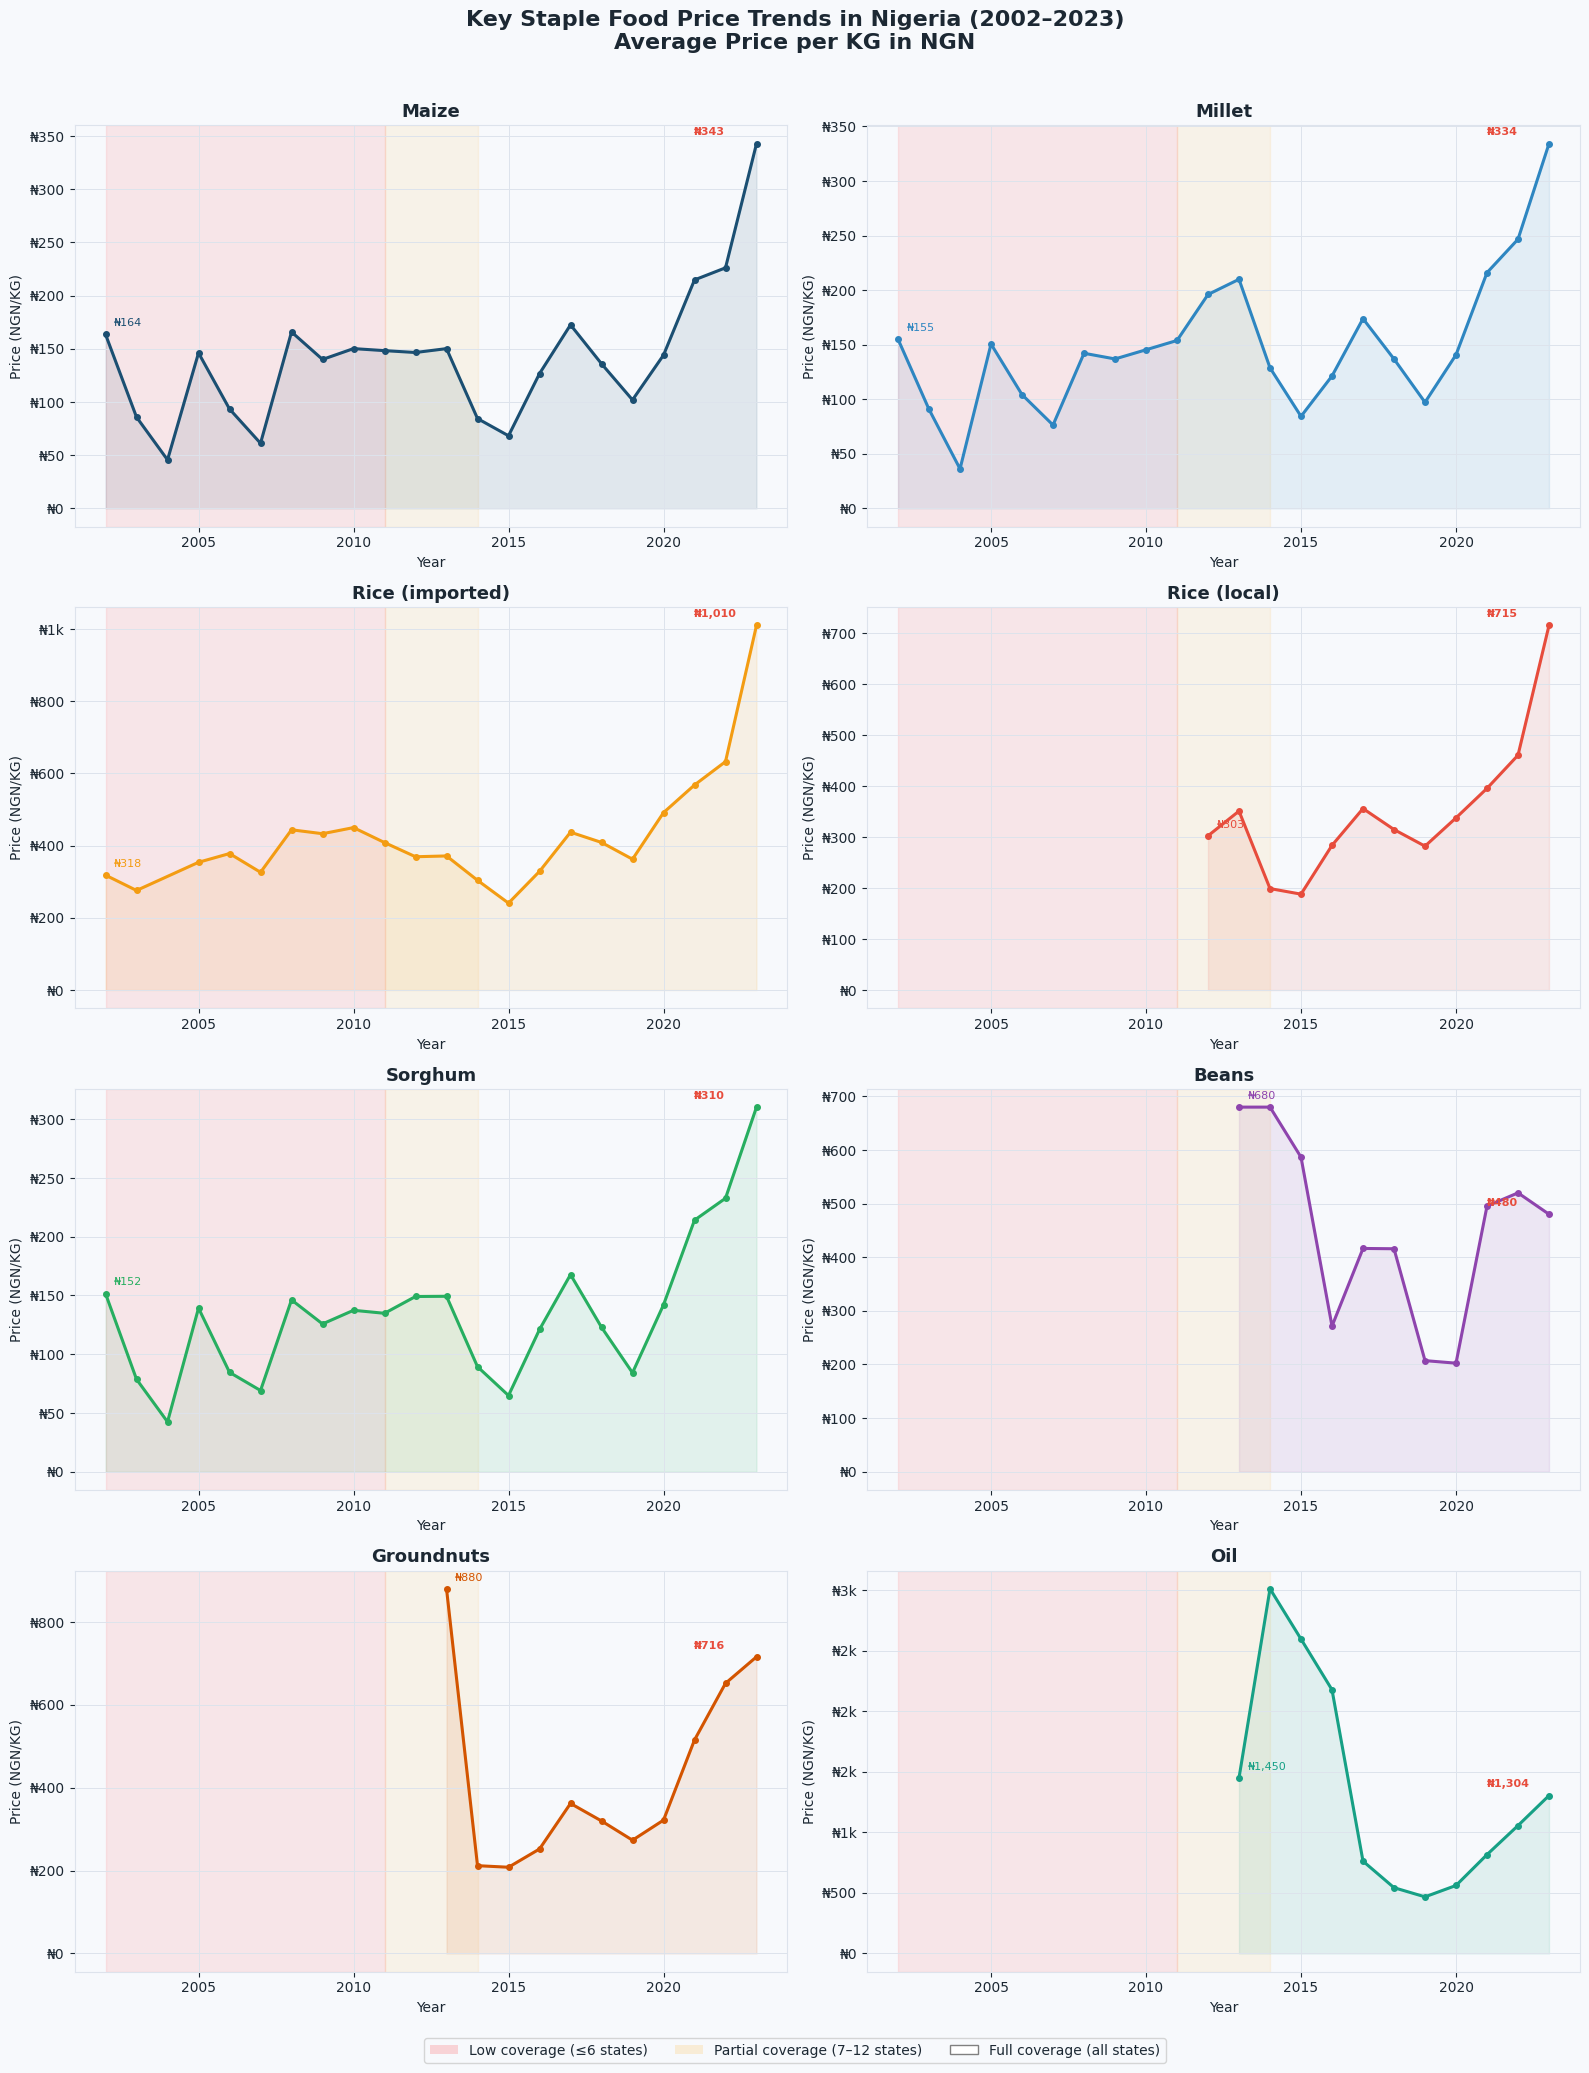

✅ Chart saved as 02_staple_price_trends.png


In [19]:
# ── Plot Price Trends ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle(
    'Key Staple Food Price Trends in Nigeria (2002–2023)\nAverage Price per KG in NGN',
    fontsize=16, fontweight='bold', y=1.01
)

for ax, commodity in zip(axes.flat, STAPLES):
    series = trends_pivot[commodity].dropna()

    if series.empty:
        ax.set_visible(False)
        continue

    # ── Shade reliability zones ───────────────────────────────────────────
    ax.axvspan(2002, 2011, alpha=0.08, color='red',    label='Low coverage')
    ax.axvspan(2011, 2014, alpha=0.08, color='orange', label='Partial coverage')

    # ── Plot line ─────────────────────────────────────────────────────────
    color = PALETTE[STAPLES.index(commodity) % len(PALETTE)]
    ax.plot(series.index, series.values,
            color=color, linewidth=2.2,
            marker='o', markersize=4, zorder=3)
    ax.fill_between(series.index, series.values,
                    alpha=0.1, color=color)

    # ── Annotate first and last values ────────────────────────────────────
    ax.annotate(f'₦{series.iloc[0]:,.0f}',
                xy=(series.index[0], series.iloc[0]),
                xytext=(6, 6), textcoords='offset points',
                fontsize=8, color=color)
    ax.annotate(f'₦{series.iloc[-1]:,.0f}',
                xy=(series.index[-1], series.iloc[-1]),
                xytext=(-45, 6), textcoords='offset points',
                fontsize=8, color=ACCENT, fontweight='bold')

    # ── Formatting ────────────────────────────────────────────────────────
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
    ax.set_title(commodity)
    ax.set_ylabel('Price (NGN/KG)')
    ax.set_xlabel('Year')
    ax.set_xlim(2001, 2024)

# ── Add a shared legend for the zones ────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red',    alpha=0.15, label='Low coverage (≤6 states)'),
    Patch(facecolor='orange', alpha=0.15, label='Partial coverage (7–12 states)'),
    Patch(facecolor='white',  edgecolor='grey', label='Full coverage (all states)'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02),
           frameon=True)

plt.tight_layout()
plt.savefig('02_staple_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 02_staple_price_trends.png")

In [20]:
# ── Isolate Rice (imported) and examine 2009–2016 closely ────────────────────
rice = kg_df[kg_df['commodity'] == 'Rice (imported)'].copy()

rice_yearly = (rice.groupby('year')
               .agg(
                   avg_price    = ('price_per_kg', 'mean'),
                   record_count = ('price_per_kg', 'count'),
                   states       = ('state', 'nunique')
               )
               .round(2))

print(rice_yearly.to_string())

      avg_price  record_count  states
year                                 
2002     318.19            19       2
2003     275.76            26       3
2005     353.81            30       3
2006     377.99             9       2
2007     326.09             7       3
2008     443.78            43       3
2009     432.95            33       4
2010     449.84            51       4
2011     408.44            53       4
2012     369.14            59       6
2013     371.36            77       8
2014     303.87            95      11
2015     240.70           140      13
2016     328.61           192      14
2017     437.13           288      14
2018     408.77           291      11
2019     362.34           301      12
2020     491.27           322      11
2021     567.87           328      12
2022     632.60           259      12
2023    1009.80           296      12


In [21]:
# ── Calculate year on year price change ──────────────────────────────────────
rice_yearly['pct_change'] = rice_yearly['avg_price'].pct_change() * 100

print(rice_yearly[['avg_price','pct_change','states']].round(2).to_string())

      avg_price  pct_change  states
year                               
2002     318.19         NaN       2
2003     275.76      -13.33       3
2005     353.81       28.30       3
2006     377.99        6.83       2
2007     326.09      -13.73       3
2008     443.78       36.09       3
2009     432.95       -2.44       4
2010     449.84        3.90       4
2011     408.44       -9.20       4
2012     369.14       -9.62       6
2013     371.36        0.60       8
2014     303.87      -18.17      11
2015     240.70      -20.79      13
2016     328.61       36.52      14
2017     437.13       33.02      14
2018     408.77       -6.49      11
2019     362.34      -11.36      12
2020     491.27       35.58      11
2021     567.87       15.59      12
2022     632.60       11.40      12
2023    1009.80       59.63      12


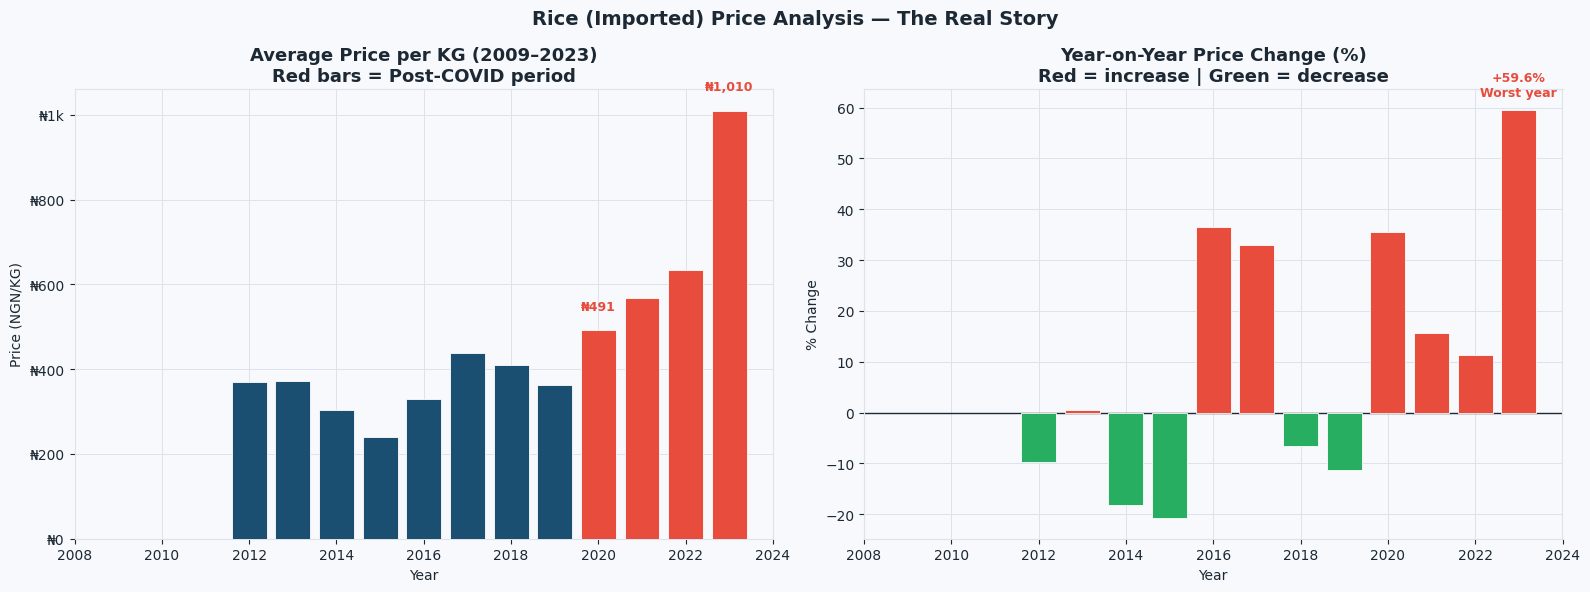

✅ Chart saved as 03_rice_price_shock.png


In [22]:
# ── Filter to reliable coverage period ───────────────────────────────────────
rice_plot = rice_yearly[rice_yearly['states'] >= 5].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Rice (Imported) Price Analysis — The Real Story',
             fontsize=14, fontweight='bold')

# ── Left chart: Full price trend ─────────────────────────────────────────────
ax = axes[0]
colors_bar = [ACCENT if y >= 2020 else BLUE for y in rice_plot.index]

ax.bar(rice_plot.index, rice_plot['avg_price'],
       color=colors_bar, edgecolor='white', linewidth=0.6, zorder=3)

# Annotate 2020 and 2023
for yr, label_offset in [(2020, 15), (2023, 15)]:
    if yr in rice_plot.index:
        val = rice_plot.loc[yr, 'avg_price']
        ax.annotate(f'₦{val:,.0f}',
                    xy=(yr, val),
                    xytext=(0, label_offset),
                    textcoords='offset points',
                    ha='center', fontsize=9,
                    color=ACCENT, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Average Price per KG (2009–2023)\nRed bars = Post-COVID period')
ax.set_ylabel('Price (NGN/KG)')
ax.set_xlabel('Year')
ax.set_xlim(2008, 2024)

# ── Right chart: Year on year % change ───────────────────────────────────────
ax = axes[1]
pct = rice_plot['pct_change'].dropna()
colors_pct = [ACCENT if v > 0 else '#27AE60' for v in pct.values]

ax.bar(pct.index, pct.values,
       color=colors_pct, edgecolor='white', linewidth=0.6, zorder=3)
ax.axhline(0, color=TEXT_CLR, linewidth=1)

# Annotate the 2023 bar
if 2023 in pct.index:
    ax.annotate(f'+{pct.loc[2023]:.1f}%\nWorst year',
                xy=(2023, pct.loc[2023]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9,
                color=ACCENT, fontweight='bold')

ax.set_title('Year-on-Year Price Change (%)\nRed = increase | Green = decrease')
ax.set_ylabel('% Change')
ax.set_xlabel('Year')
ax.set_xlim(2008, 2024)

plt.tight_layout()
plt.savefig('03_rice_price_shock.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 03_rice_price_shock.png")

---
##  Regional Price Comparison
Food prices are not uniform across Nigeria — geography, infrastructure, 
conflict, and market access all create significant price differences between 
states. Here we compare average food prices across all 14 states to identify 
which populations face the highest food costs.

We use 2015–2023 data only to ensure all states are fairly represented 
with consistent coverage.

In [23]:
# ── Average price per state (2015–2023) ──────────────────────────────────────
state_prices = (kg_df[kg_df['year'] >= 2015]
                .groupby('state')
                .agg(
                    avg_price    = ('price_per_kg', 'mean'),
                    record_count = ('price_per_kg', 'count'),
                    commodities  = ('commodity_grp', 'nunique')
                )
                .round(2)
                .sort_values('avg_price', ascending=False))

print(state_prices.to_string())

         avg_price  record_count  commodities
state                                        
Borno      1200.70         14459           24
Adamawa    1122.35          1575           24
Yobe        701.34         15146           24
Abia        478.30           816           12
Gombe       362.08          1422           12
Kebbi       341.86          1388           12
Lagos       341.41          1310           12
Oyo         282.20          1417           12
Jigawa      279.05          1291           12
Kaduna      273.89          2505           12
Kano        269.76          1347           12
Katsina     249.98          1423           12
Zamfara     241.90          1427           12
Sokoto      209.16            89            4


In [24]:
# ── Flag low coverage states ──────────────────────────────────────────────────
LOW_COVERAGE_STATES = state_prices[state_prices['record_count'] < 500].index.tolist()

print("States with low coverage (< 500 records):", LOW_COVERAGE_STATES)
print("\nThese will be flagged on the chart but not removed.")

States with low coverage (< 500 records): ['Sokoto']

These will be flagged on the chart but not removed.


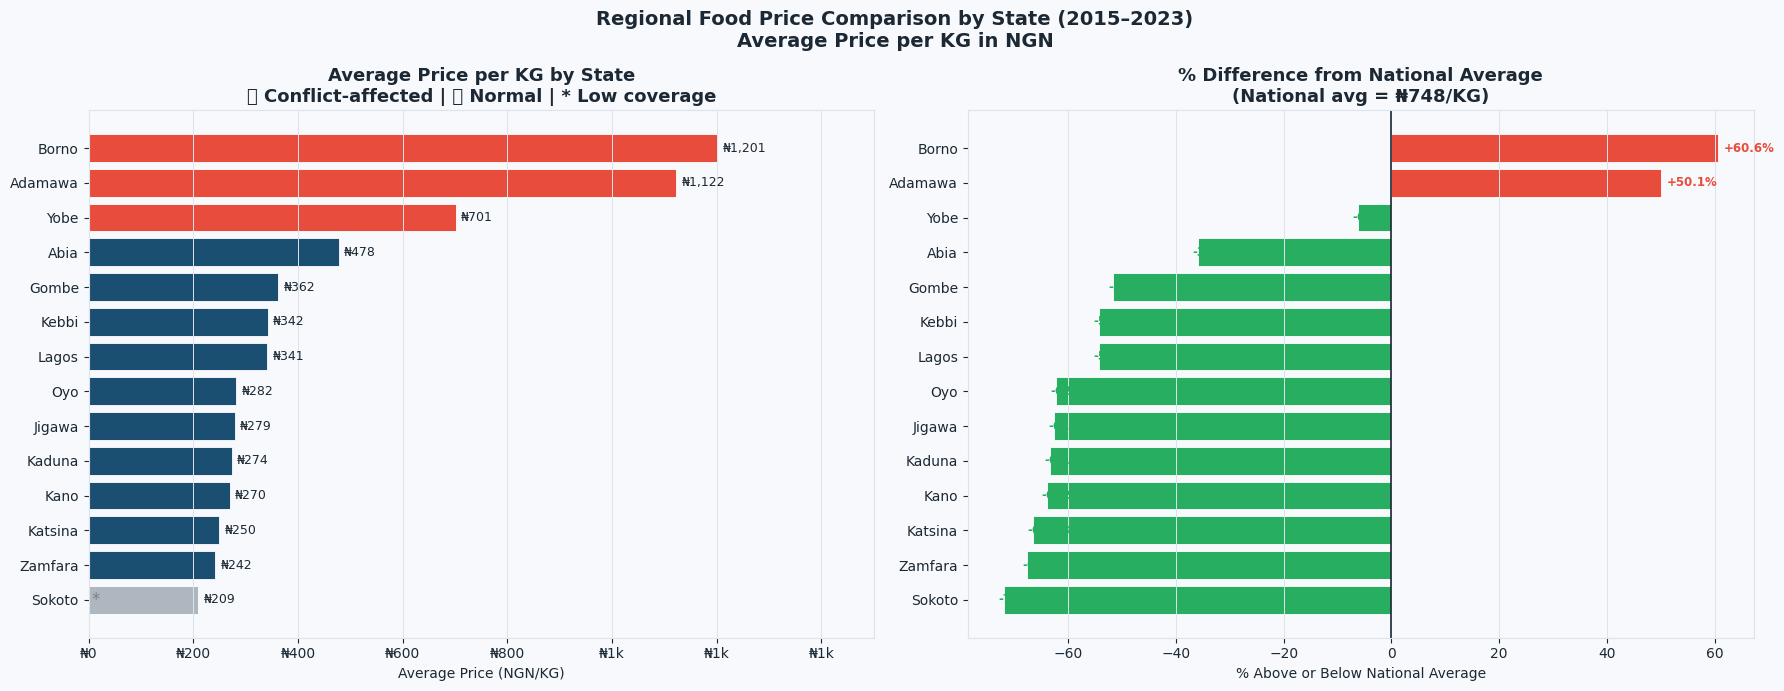


National average: ₦748/KG
✅ Chart saved as 04_regional_comparison.png


In [25]:
# ── Plot Regional Price Comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Regional Food Price Comparison by State (2015–2023)\nAverage Price per KG in NGN',
             fontsize=14, fontweight='bold')

# ── Left chart: Average price per state ──────────────────────────────────────
ax = axes[0]

# Assign colours — conflict states red, low coverage grey, rest blue
CONFLICT_STATES = ['Borno', 'Adamawa', 'Yobe']

colors_state = []
for state in state_prices.index:
    if state in CONFLICT_STATES:
        colors_state.append(ACCENT)
    elif state in LOW_COVERAGE_STATES:
        colors_state.append('#AEB6BF')
    else:
        colors_state.append(BLUE)

bars = ax.barh(state_prices.index[::-1],
               state_prices['avg_price'][::-1],
               color=colors_state[::-1],
               edgecolor='white', linewidth=0.6)

# Annotate each bar
for bar, val in zip(bars, state_prices['avg_price'][::-1]):
    ax.text(val + 10,
            bar.get_y() + bar.get_height() / 2,
            f'₦{val:,.0f}',
            va='center', fontsize=9, color=TEXT_CLR)

# Flag low coverage states with asterisk
for i, state in enumerate(state_prices.index[::-1]):
    if state in LOW_COVERAGE_STATES:
        ax.text(5, i, '*', va='center', fontsize=12, color='grey')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Average Price per KG by State\n🔴 Conflict-affected | 🔵 Normal | * Low coverage')
ax.set_xlabel('Average Price (NGN/KG)')
ax.set_xlim(0, state_prices['avg_price'].max() * 1.25)
ax.grid(axis='y', alpha=0)

# ── Right chart: Price gap vs national average ────────────────────────────────
ax = axes[1]

national_avg = kg_df[kg_df['year'] >= 2015]['price_per_kg'].mean().round(2)
state_prices['gap_vs_national'] = (
    (state_prices['avg_price'] - national_avg) / national_avg * 100
).round(1)

colors_gap = [ACCENT if v > 0 else '#27AE60'
              for v in state_prices['gap_vs_national'][::-1]]

ax.barh(state_prices.index[::-1],
        state_prices['gap_vs_national'][::-1],
        color=colors_gap, edgecolor='white', linewidth=0.6)

ax.axvline(0, color=TEXT_CLR, linewidth=1.2)
ax.set_title(f'% Difference from National Average\n(National avg = ₦{national_avg:,.0f}/KG)')
ax.set_xlabel('% Above or Below National Average')

# Annotate bars
for i, (state, row) in enumerate(state_prices[::-1].iterrows()):
    val = row['gap_vs_national']
    offset = 1 if val >= 0 else -1
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:+.1f}%',
            va='center', fontsize=8.5,
            color=ACCENT if val > 0 else '#27AE60',
            fontweight='bold')

ax.grid(axis='y', alpha=0)

plt.tight_layout()
plt.savefig('04_regional_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nNational average: ₦{national_avg:,.0f}/KG")
print("✅ Chart saved as 04_regional_comparison.png")

---
##  Naira Depreciation & Inflation
Food prices in NGN have risen dramatically — but how much of that is real 
food price inflation versus simply the Naira losing value against the dollar?
Here we separate the two effects by comparing NGN prices against USD prices 
and tracking the implied exchange rate over time.

Understanding this distinction matters for programming — if prices are rising 
because of currency depreciation, the solution is different from a supply shock.

In [26]:
# ── Yearly average NGN and USD price + implied exchange rate ─────────────────
yearly_fx = (kg_df.groupby('year')
             .agg(
                 avg_ngn = ('price_per_kg',     'mean'),
                 avg_usd = ('price_usd_per_kg', 'mean')
             )
             .round(4))

yearly_fx['implied_rate'] = (yearly_fx['avg_ngn'] / yearly_fx['avg_usd']).round(2)
yearly_fx['ngn_pct_change'] = yearly_fx['avg_ngn'].pct_change() * 100
yearly_fx['usd_pct_change'] = yearly_fx['avg_usd'].pct_change() * 100

print(yearly_fx.to_string())

        avg_ngn  avg_usd  implied_rate  ngn_pct_change  usd_pct_change
year                                                                  
2002   202.8560   1.6889        120.11             NaN             NaN
2003   131.5881   1.0213        128.84      -35.132261      -39.528687
2004    41.7273   0.3180        131.22      -68.289458      -68.863214
2005   194.1718   1.4846        130.79      365.335164      366.855346
2006   136.8701   1.0788        126.87      -29.510825      -27.333962
2007    99.3924   0.8047        123.51      -27.381948      -25.407861
2008   223.3225   1.8950        117.85      124.687702      135.491488
2009   197.6361   1.3191        149.83      -11.501931      -30.390501
2010   216.7225   1.4394        150.56        9.657345        9.119854
2011   211.1445   1.3618        155.05       -2.573798       -5.391135
2012   212.6269   1.3537        157.07        0.702078       -0.594801
2013   464.2459   2.9540        157.16      118.338272      118.216739
2014  

In [27]:
# ── Investigate what is driving the 2023 spike ───────────────────────────────
yr2023 = kg_df[kg_df['year'] == 2023]

print("=== 2023 Average Price per Commodity ===")
print(yr2023.groupby('commodity_grp')['price_per_kg']
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .to_string())

print("\n=== 2023 Average Price per Category ===")
print(yr2023.groupby('category')['price_per_kg']
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .to_string())

=== 2023 Average Price per Commodity ===
commodity_grp
Milk                      75551.96
Sugar                      4250.09
Meat                       2651.21
Oil                        1303.57
Rice (imported)            1009.80
Fuel (diesel)               895.83
Groundnuts                  715.88
Rice (local)                715.41
Beans                       480.24
Fish                        479.64
Yam                         464.97
Cowpeas                     450.80
Salt                        439.25
Oranges                     370.26
Maize                       342.82
Millet                      334.15
Gari/Cassava                324.30
Sorghum                     310.28
Fuel (petrol-gasoline)      292.86
Onions                      291.89
Tomatoes                    267.27
Bananas                     257.37
Spinach                     247.76
Watermelons                 221.22

=== 2023 Average Price per Category ===
category
milk and dairy           75551.96
miscellaneous food   

In [28]:
# ── Define exclusions ────────────────────────────────────────────────────────
EXCLUDE_COMMODITIES = ['Milk', 'Fuel (diesel)', 'Fuel (petrol-gasoline)']
EXCLUDE_CATEGORIES  = ['non-food']

# ── Apply to kg_df ───────────────────────────────────────────────────────────
kg_df_food = kg_df[
    (~kg_df['commodity_grp'].isin(EXCLUDE_COMMODITIES)) &
    (~kg_df['category'].isin(EXCLUDE_CATEGORIES))
].copy()

print(f"kg_df rows before exclusion: {len(kg_df):,}")
print(f"kg_df rows after exclusion:  {len(kg_df_food):,}")
print(f"Rows removed:                {len(kg_df) - len(kg_df_food):,}")

print("\n=== Verify 2023 average after exclusion ===")
print(kg_df_food[kg_df_food['year'] == 2023]
      .groupby('commodity_grp')['price_per_kg']
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .to_string())

kg_df rows before exclusion: 48,533
kg_df rows after exclusion:  45,619
Rows removed:                2,914

=== Verify 2023 average after exclusion ===
commodity_grp
Sugar              4250.09
Meat               2651.21
Oil                1303.57
Rice (imported)    1009.80
Groundnuts          715.88
Rice (local)        715.41
Beans               480.24
Fish                479.64
Yam                 464.97
Cowpeas             450.80
Salt                439.25
Oranges             370.26
Maize               342.82
Millet              334.15
Gari/Cassava        324.30
Sorghum             310.28
Onions              291.89
Tomatoes            267.27
Bananas             257.37
Spinach             247.76
Watermelons         221.22


In [29]:
# ── Check Sugar records ──────────────────────────────────────────────────────
sugar = kg_df_food[kg_df_food['commodity_grp'] == 'Sugar']

print(sugar.groupby(['year','unit'])['price_per_kg']
      .mean()
      .round(2)
      .to_string())

year  unit  
2013  500 G     6000.00
2014  500 G     6000.00
2015  500 G     4800.00
2017  1.3 KG     660.37
2018  1.3 KG     496.63
2019  1.3 KG     374.54
2020  1.3 KG     447.93
2021  1.3 KG     493.57
2022  1.3 KG     579.82
      500 G     3800.00
2023  1.3 KG     865.40
      500 G     5219.58


In [30]:
# ── Exclude 500G sugar records — unrepresentative premium packs ──────────────
sugar_500g_mask = (
    (kg_df_food['commodity_grp'] == 'Sugar') &
    (kg_df_food['unit'] == '500 G')
)

print(f"Sugar 500G records to remove: {sugar_500g_mask.sum()}")

kg_df_food = kg_df_food[~sugar_500g_mask].copy()

print(f"kg_df_food rows after sugar fix: {len(kg_df_food):,}")

# ── Verify sugar now looks clean ─────────────────────────────────────────────
print("\n=== Sugar per KG after fix ===")
print(kg_df_food[kg_df_food['commodity_grp'] == 'Sugar']
      .groupby('year')['price_per_kg']
      .mean()
      .round(2)
      .to_string())

Sugar 500G records to remove: 204
kg_df_food rows after sugar fix: 45,415

=== Sugar per KG after fix ===
year
2017    660.37
2018    496.63
2019    374.54
2020    447.93
2021    493.57
2022    579.82
2023    865.40


In [31]:
# ── Rebuild yearly averages using clean kg_df_food ───────────────────────────
yearly_fx = (kg_df_food.groupby('year')
             .agg(
                 avg_ngn = ('price_per_kg',     'mean'),
                 avg_usd = ('price_usd_per_kg', 'mean')
             )
             .round(4))

yearly_fx['implied_rate']   = (yearly_fx['avg_ngn'] / yearly_fx['avg_usd']).round(2)
yearly_fx['ngn_pct_change'] = yearly_fx['avg_ngn'].pct_change().mul(100).round(2)
yearly_fx['usd_pct_change'] = yearly_fx['avg_usd'].pct_change().mul(100).round(2)

print(yearly_fx.to_string())

       avg_ngn  avg_usd  implied_rate  ngn_pct_change  usd_pct_change
year                                                                 
2002  202.8560   1.6889        120.11             NaN             NaN
2003  131.5881   1.0213        128.84          -35.13          -39.53
2004   41.7273   0.3180        131.22          -68.29          -68.86
2005  194.1718   1.4846        130.79          365.34          366.86
2006  136.8701   1.0788        126.87          -29.51          -27.33
2007   99.3924   0.8047        123.51          -27.38          -25.41
2008  223.3225   1.8950        117.85          124.69          135.49
2009  197.6361   1.3191        149.83          -11.50          -30.39
2010  216.7225   1.4394        150.56            9.66            9.12
2011  211.1445   1.3618        155.05           -2.57           -5.39
2012  212.6269   1.3537        157.07            0.70           -0.59
2013  234.6694   1.4943        157.04           10.37           10.39
2014  280.4141   1.7

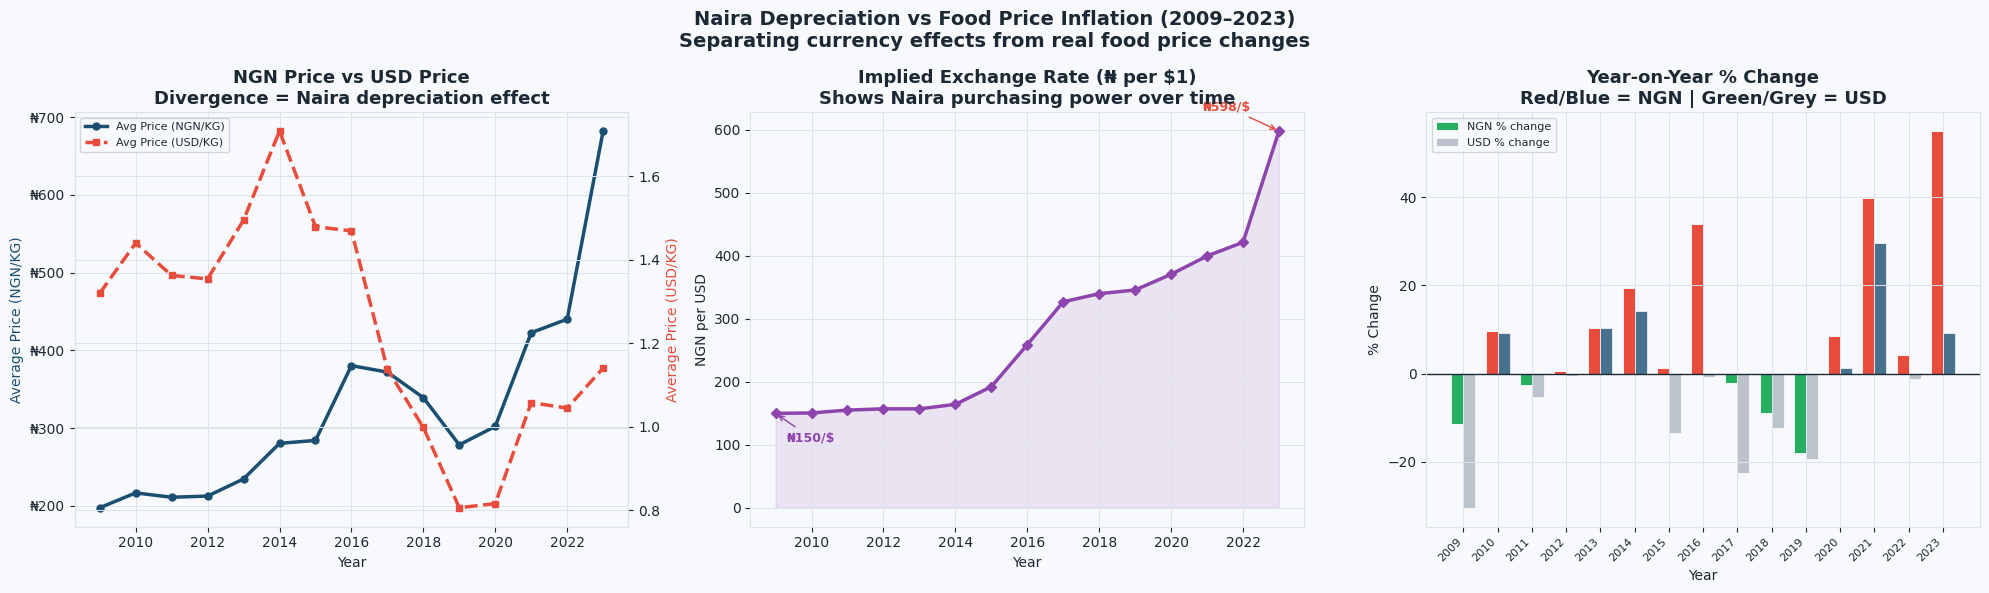

✅ Chart saved as 05_naira_depreciation.png


In [32]:
# ── Filter to reliable years only (5+ states) ────────────────────────────────
fx_plot = yearly_fx[yearly_fx.index >= 2009].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Naira Depreciation vs Food Price Inflation (2009–2023)\n'
    'Separating currency effects from real food price changes',
    fontsize=14, fontweight='bold'
)

# ── Left: NGN vs USD average price ───────────────────────────────────────────
ax = axes[0]
ax2 = ax.twinx()

l1, = ax.plot(fx_plot.index, fx_plot['avg_ngn'],
              color=BLUE, linewidth=2.5,
              marker='o', markersize=5, label='Avg Price (NGN/KG)')
l2, = ax2.plot(fx_plot.index, fx_plot['avg_usd'],
               color=ACCENT, linewidth=2.5,
               marker='s', markersize=5,
               linestyle='--', label='Avg Price (USD/KG)')

ax.set_ylabel('Average Price (NGN/KG)', color=BLUE)
ax2.set_ylabel('Average Price (USD/KG)', color=ACCENT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('NGN Price vs USD Price\nDivergence = Naira depreciation effect')
ax.set_xlabel('Year')
ax.legend(handles=[l1, l2], loc='upper left', fontsize=8)

# ── Middle: Implied exchange rate ─────────────────────────────────────────────
ax = axes[1]
ax.plot(fx_plot.index, fx_plot['implied_rate'],
        color='#8E44AD', linewidth=2.5,
        marker='D', markersize=5)
ax.fill_between(fx_plot.index, fx_plot['implied_rate'],
                alpha=0.12, color='#8E44AD')

# Annotate start and end
ax.annotate(f'₦{fx_plot["implied_rate"].iloc[0]:,.0f}/$',
            xy=(fx_plot.index[0], fx_plot['implied_rate'].iloc[0]),
            xytext=(8, -20), textcoords='offset points',
            fontsize=9, color='#8E44AD', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#8E44AD'))
ax.annotate(f'₦{fx_plot["implied_rate"].iloc[-1]:,.0f}/$',
            xy=(fx_plot.index[-1], fx_plot['implied_rate'].iloc[-1]),
            xytext=(-55, 15), textcoords='offset points',
            fontsize=9, color=ACCENT, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT))

ax.set_title('Implied Exchange Rate (₦ per $1)\nShows Naira purchasing power over time')
ax.set_ylabel('NGN per USD')
ax.set_xlabel('Year')

# ── Right: NGN vs USD % change side by side ───────────────────────────────────
ax = axes[2]
pct = fx_plot[['ngn_pct_change', 'usd_pct_change']].dropna()
x    = np.arange(len(pct))
width = 0.35

bars1 = ax.bar(x - width/2, pct['ngn_pct_change'],
               width, label='NGN % change',
               color=[ACCENT if v > 0 else '#27AE60'
                      for v in pct['ngn_pct_change']],
               edgecolor='white', linewidth=0.6)
bars2 = ax.bar(x + width/2, pct['usd_pct_change'],
               width, label='USD % change',
               color=[BLUE if v > 0 else '#AEB6BF'
                      for v in pct['usd_pct_change']],
               edgecolor='white', linewidth=0.6, alpha=0.8)

ax.axhline(0, color=TEXT_CLR, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(pct.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Year-on-Year % Change\nRed/Blue = NGN | Green/Grey = USD')
ax.set_ylabel('% Change')
ax.set_xlabel('Year')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('05_naira_depreciation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 05_naira_depreciation.png")

---
##  Seasonality Analysis
Food prices in Nigeria are not constant throughout the year — they follow 
predictable seasonal patterns driven by agricultural harvest cycles.
Understanding these patterns helps WFP and partners time interventions 
more effectively and anticipate when households are most vulnerable.

The key concept here is the **lean season** — the period between when 
last season's harvest runs out and the new harvest arrives. During this 
window food stocks are low, prices peak and poor households are most 
at risk of reducing meals or skipping food entirely.

In [33]:
# ── Monthly average price across all years ───────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Overall monthly average
monthly_overall = (kg_df_food.groupby('month')['price_per_kg']
                   .mean()
                   .round(2))

# Monthly average per key staple
SEASON_STAPLES = ['Maize', 'Millet', 'Sorghum', 'Rice (imported)']

monthly_staples = (kg_df_food[kg_df_food['commodity_grp'].isin(SEASON_STAPLES)]
                   .groupby(['month', 'commodity_grp'])['price_per_kg']
                   .mean()
                   .round(2)
                   .unstack())

print("=== Overall Monthly Average (NGN/KG) ===")
for i, val in monthly_overall.items():
    print(f"  {month_names[i-1]:>3}: ₦{val:,.2f}")

print("\n=== Monthly Average per Staple ===")
print(monthly_staples.to_string())

=== Overall Monthly Average (NGN/KG) ===
  Jan: ₦381.82
  Feb: ₦370.93
  Mar: ₦361.50
  Apr: ₦356.10
  May: ₦392.76
  Jun: ₦399.02
  Jul: ₦403.81
  Aug: ₦394.15
  Sep: ₦402.01
  Oct: ₦387.23
  Nov: ₦400.23
  Dec: ₦358.56

=== Monthly Average per Staple ===
commodity_grp   Maize  Millet  Rice (imported)  Sorghum
month                                                  
1              160.96  167.21           507.25   154.15
2              153.17  157.47           490.60   139.96
3              158.17  169.60           477.73   150.10
4              157.27  168.11           481.39   149.54
5              167.44  173.02           503.23   156.93
6              187.05  182.23           528.40   173.11
7              185.43  195.39           485.94   174.92
8              173.89  198.48           488.58   178.59
9              172.98  179.02           502.53   179.56
10             154.87  169.59           510.46   166.20
11             155.40  175.14           506.63   169.39
12             

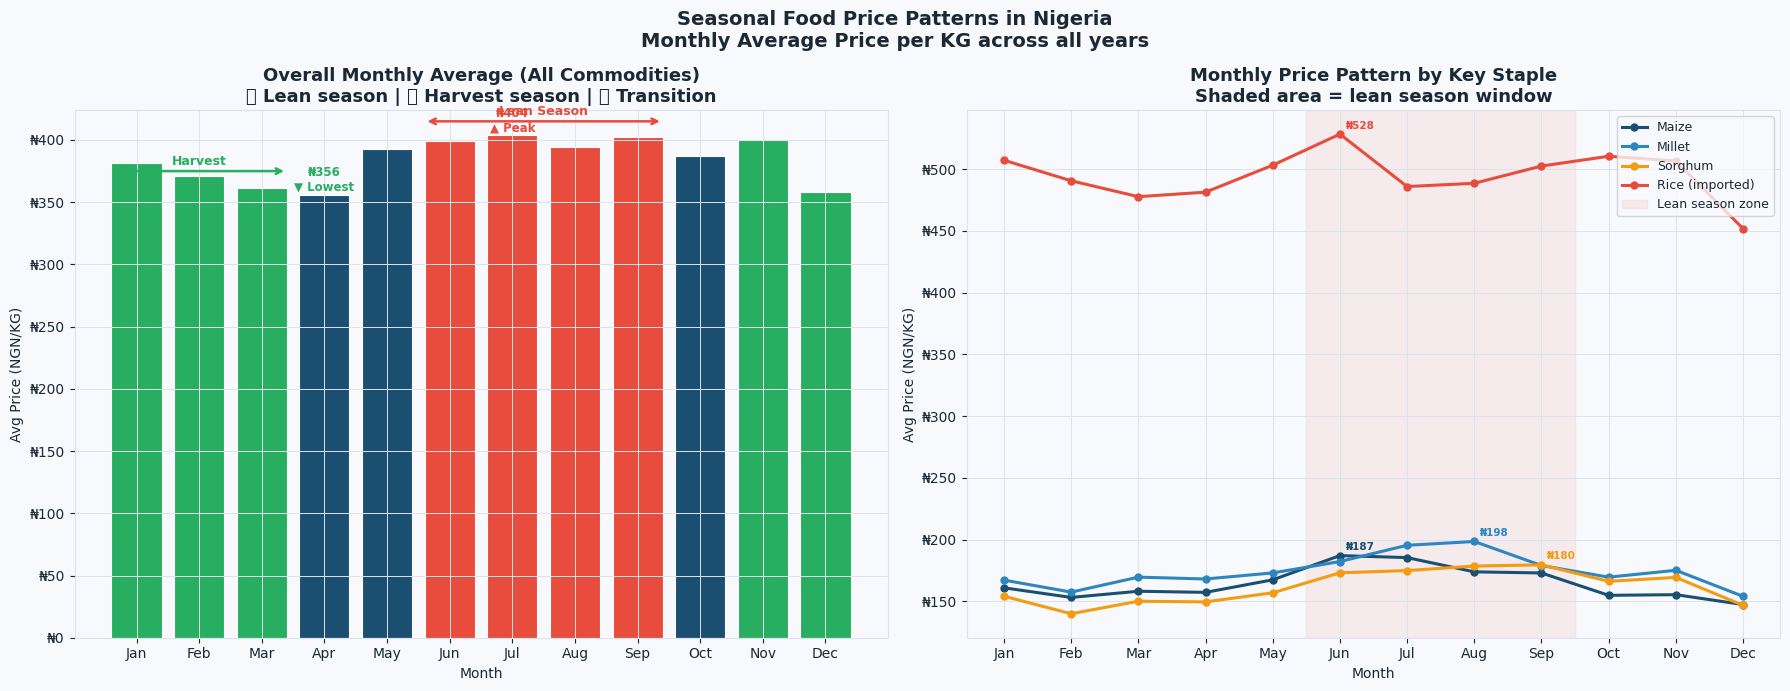

✅ Chart saved as 06_seasonality.png


In [34]:
# ── Plot Seasonality ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Seasonal Food Price Patterns in Nigeria\n'
    'Monthly Average Price per KG across all years',
    fontsize=14, fontweight='bold'
)

# ── Left: Overall monthly average as bar chart ────────────────────────────────
ax = axes[0]

# Colour bars by season — lean season red, harvest green, transition blue
LEAN_MONTHS    = [6, 7, 8, 9]
HARVEST_MONTHS = [11, 12, 1, 2, 3]

colors_month = []
for m in monthly_overall.index:
    if m in LEAN_MONTHS:
        colors_month.append(ACCENT)
    elif m in HARVEST_MONTHS:
        colors_month.append('#27AE60')
    else:
        colors_month.append(BLUE)

bars = ax.bar(range(1, 13), monthly_overall.values,
              color=colors_month, edgecolor='white', linewidth=0.8)

# Annotate peak and lowest month
peak_month = monthly_overall.idxmax()
low_month  = monthly_overall.idxmin()

for m, val in monthly_overall.items():
    if m == peak_month:
        ax.text(m, val + 3, f'₦{val:,.0f}\n▲ Peak',
                ha='center', fontsize=8.5,
                color=ACCENT, fontweight='bold')
    elif m == low_month:
        ax.text(m, val + 3, f'₦{val:,.0f}\n▼ Lowest',
                ha='center', fontsize=8.5,
                color='#27AE60', fontweight='bold')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Overall Monthly Average (All Commodities)\n'
             '🔴 Lean season | 🟢 Harvest season | 🔵 Transition')
ax.set_ylabel('Avg Price (NGN/KG)')
ax.set_xlabel('Month')

# Add lean season annotation bracket
ax.annotate('', xy=(9.4, 415), xytext=(5.6, 415),
            arrowprops=dict(arrowstyle='<->', color=ACCENT, lw=1.8))
ax.text(7.5, 420, 'Lean Season', ha='center',
        fontsize=9, color=ACCENT, fontweight='bold')

# Add harvest annotation bracket
ax.annotate('', xy=(3.4, 375), xytext=(0.6, 375),
            arrowprops=dict(arrowstyle='<->', color='#27AE60', lw=1.8))
ax.text(2.0, 380, 'Harvest', ha='center',
        fontsize=9, color='#27AE60', fontweight='bold')

# ── Right: Line chart per staple ──────────────────────────────────────────────
ax = axes[1]

for i, commodity in enumerate(SEASON_STAPLES):
    if commodity in monthly_staples.columns:
        ax.plot(range(1, 13), monthly_staples[commodity].values,
                color=PALETTE[i], linewidth=2.2,
                marker='o', markersize=5, label=commodity)

        # Annotate peak month for each commodity
        peak_idx = monthly_staples[commodity].idxmax()
        peak_val = monthly_staples[commodity].max()
        ax.annotate(f'₦{peak_val:,.0f}',
                    xy=(peak_idx, peak_val),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=7.5, color=PALETTE[i], fontweight='bold')

# Shade lean season
ax.axvspan(5.5, 9.5, alpha=0.08, color=ACCENT, label='Lean season zone')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Monthly Price Pattern by Key Staple\nShaded area = lean season window')
ax.set_ylabel('Avg Price (NGN/KG)')
ax.set_xlabel('Month')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('06_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 06_seasonality.png")

---
##  Food Category Analysis
Not all food categories behave the same way. Some are expensive but stable,
others are cheap but volatile. Understanding which categories drive the overall
food price index — and which are most sensitive to shocks — helps prioritise 
which commodities to monitor most closely and which food groups are becoming 
increasingly out of reach for poor households.

The dataset covers 8 food categories:
- Cereals and tubers
- Pulses and nuts
- Vegetables and fruits
- Meat, fish and eggs
- Oil and fats
- Miscellaneous food
- Milk and dairy
- Non-food (excluded from this analysis)

In [35]:
# ── Clean Oil Records — All fixes in one place ────────────────────────────────

# Step 1: Remove 100 L and 100 KG oil records (industrial bulk, not household)
mask_bulk = (
    (kg_df_food['commodity_grp'] == 'Oil') &
    (kg_df_food['unit'].isin(['100 L', '100 KG']))
)

# Step 2: Remove L-unit oil records (inconsistent across years, unreliable)
mask_L = (
    (kg_df_food['commodity_grp'] == 'Oil') &
    (kg_df_food['unit'] == 'L')
)

# Step 3: Combine both masks and remove together
combined_mask = mask_bulk | mask_L

print(f"Bulk oil records (100 L, 100 KG): {mask_bulk.sum()}")
print(f"L-unit oil records:                {mask_L.sum()}")
print(f"Total oil records to remove:       {combined_mask.sum()}")

kg_df_food = kg_df_food[~combined_mask].copy()

print(f"\nkg_df_food rows after all oil fixes: {len(kg_df_food):,}")

# ── Verify ────────────────────────────────────────────────────────────────────
print("\n=== Oil after all fixes (750 ML only) ===")
print(kg_df_food[kg_df_food['commodity_grp'] == 'Oil']
      .groupby(['year', 'unit'])['price_per_kg']
      .mean()
      .round(2)
      .to_string())

Bulk oil records (100 L, 100 KG): 58
L-unit oil records:                1277
Total oil records to remove:       1335

kg_df_food rows after all oil fixes: 44,080

=== Oil after all fixes (750 ML only) ===
year  unit  
2016  750 ML     523.47
2017  750 ML     735.27
2018  750 ML     585.08
2019  750 ML     473.89
2020  750 ML     584.00
2021  750 ML     835.23
2022  750 ML    1106.21
2023  750 ML    1275.63


In [36]:
# ── Average price and record count per category ──────────────────────────────
cat_summary = (kg_df_food.groupby('category')
               .agg(
                   avg_price    = ('price_per_kg', 'mean'),
                   record_count = ('price_per_kg', 'count'),
                   commodities  = ('commodity_grp', 'nunique')
               )
               .round(2)
               .sort_values('avg_price', ascending=False))

print("=== Category Summary ===")
print(cat_summary.to_string())

# ── Yearly trend per category ─────────────────────────────────────────────────
cat_trend = (kg_df_food[kg_df_food['year'] >= 2015]
             .groupby(['year', 'category'])['price_per_kg']
             .mean()
             .round(2)
             .unstack())

print("\n=== Yearly Average per Category (2015–2023) ===")
print(cat_trend.to_string())

=== Category Summary ===
                       avg_price  record_count  commodities
category                                                   
meat, fish and eggs      1071.15          2967            2
oil and fats              700.57          1897            1
miscellaneous food        629.60          1696            2
pulses and nuts           360.18          8651            4
cereals and tubers        247.26         23365            8
vegetables and fruits     203.67          5504            6

=== Yearly Average per Category (2015–2023) ===
category  cereals and tubers  meat, fish and eggs  miscellaneous food  oil and fats  pulses and nuts  vegetables and fruits
year                                                                                                                       
2015                  118.98              1750.00              260.00           NaN           164.20                 211.33
2016                  179.97               856.83              240.00     

In [37]:
# ── Rebuild category trend with clean data ────────────────────────────────────
cat_trend = (kg_df_food[kg_df_food['year'] >= 2015]
             .groupby(['year', 'category'])['price_per_kg']
             .mean()
             .round(2)
             .unstack())

print(cat_trend.to_string())

category  cereals and tubers  meat, fish and eggs  miscellaneous food  oil and fats  pulses and nuts  vegetables and fruits
year                                                                                                                       
2015                  118.98              1750.00              260.00           NaN           164.20                 211.33
2016                  179.97               856.83              240.00        523.47           225.55                 122.46
2017                  236.72               852.40             1198.10        735.27           352.09                 172.71
2018                  206.27               851.74              689.08        585.08           343.84                 171.99
2019                  170.04               857.67              531.30        473.89           216.53                 198.42
2020                  224.10               894.01              534.07        584.00           237.18                 175.83
2021    

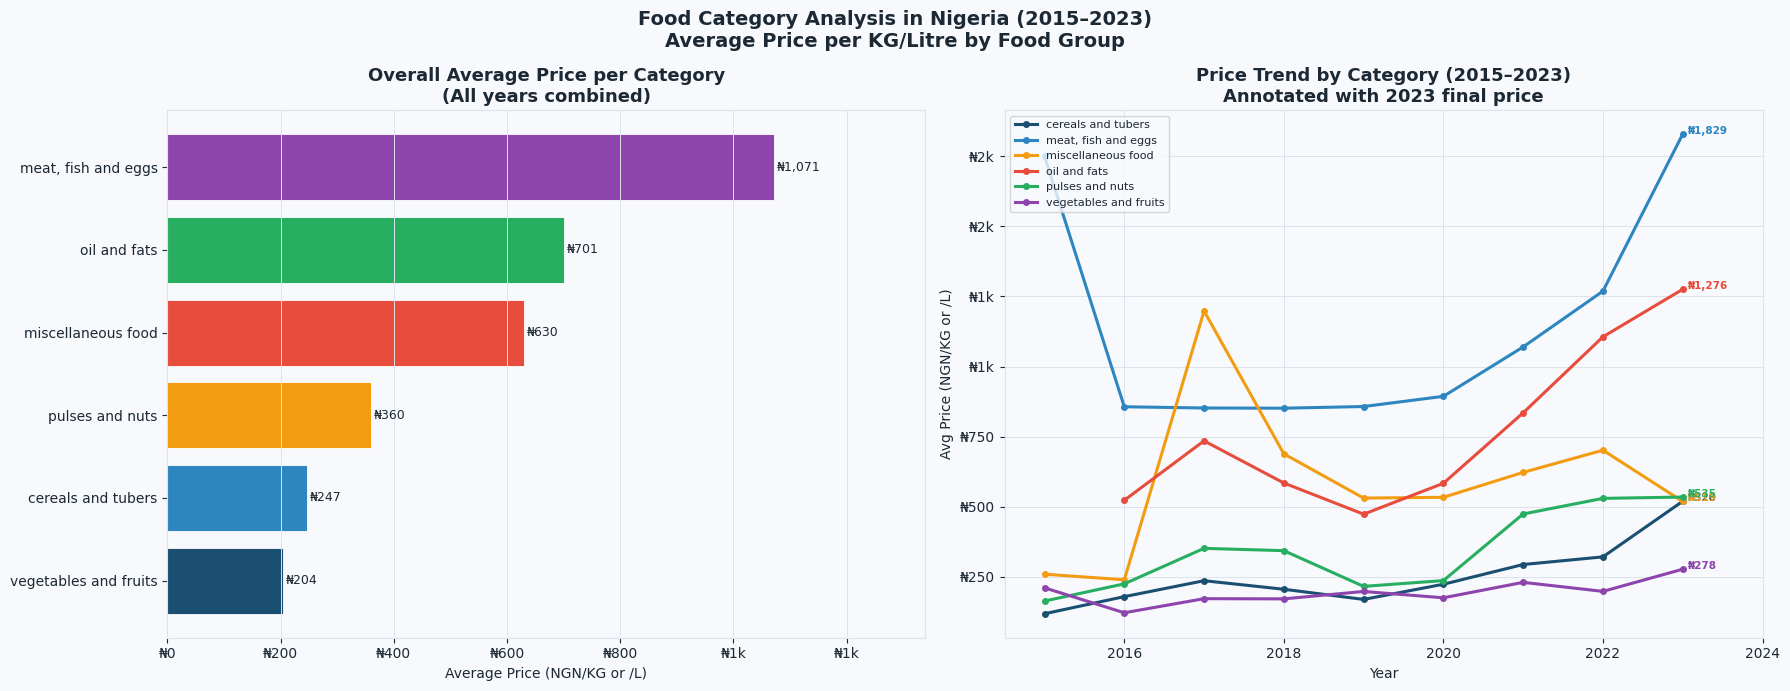

✅ Chart saved as 07_category_analysis.png


In [38]:
# ── Plot Category Analysis ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Food Category Analysis in Nigeria (2015–2023)\n'
    'Average Price per KG/Litre by Food Group',
    fontsize=14, fontweight='bold'
)

# ── Left: Average price per category ─────────────────────────────────────────
ax = axes[0]

cat_summary_clean = (kg_df_food.groupby('category')['price_per_kg']
                     .mean()
                     .round(2)
                     .sort_values(ascending=True))

colors_cat = [PALETTE[i % len(PALETTE)]
              for i in range(len(cat_summary_clean))]

bars = ax.barh(cat_summary_clean.index,
               cat_summary_clean.values,
               color=colors_cat,
               edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, cat_summary_clean.values):
    ax.text(val + 5,
            bar.get_y() + bar.get_height() / 2,
            f'₦{val:,.0f}',
            va='center', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Overall Average Price per Category\n(All years combined)')
ax.set_xlabel('Average Price (NGN/KG or /L)')
ax.set_xlim(0, cat_summary_clean.max() * 1.25)
ax.grid(axis='y', alpha=0)

# ── Right: Trend per category 2015–2023 ──────────────────────────────────────
ax = axes[1]

for i, col in enumerate(cat_trend.columns):
    series = cat_trend[col].dropna()
    ax.plot(series.index, series.values,
            color=PALETTE[i % len(PALETTE)],
            linewidth=2.2, marker='o', markersize=4,
            label=col)

    # Annotate 2023 value
    if 2023 in series.index:
        ax.annotate(f'₦{series.loc[2023]:,.0f}',
                    xy=(2023, series.loc[2023]),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=7.5,
                    color=PALETTE[i % len(PALETTE)],
                    fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Price Trend by Category (2015–2023)\nAnnotated with 2023 final price')
ax.set_ylabel('Avg Price (NGN/KG or /L)')
ax.set_xlabel('Year')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(2014.5, 2024)

plt.tight_layout()
plt.savefig('07_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 07_category_analysis.png")

---
##  Retail vs Wholesale Price Analysis
Wholesale prices are what traders pay when buying in bulk directly from 
producers or large distributors. Retail prices are what households actually 
pay in local markets. The gap between the two is the trader markup — 
the cost of moving food from bulk supply to household level.

Understanding this gap matters for two reasons:
1. It shows how much of the final food cost is driven by the supply chain 
   rather than production costs
2. A widening gap over time signals increasing inefficiency or exploitation 
   in food markets — both of which hurt poor households disproportionately

In [39]:
# ── Retail vs Wholesale yearly average ───────────────────────────────────────
rw_trend = (kg_df_food.groupby(['year', 'price_type'])['price_per_kg']
            .mean()
            .round(2)
            .unstack())

# ── Calculate markup percentage ───────────────────────────────────────────────
rw_trend['markup_pct'] = (
    (rw_trend['Retail'] - rw_trend['Wholesale']) /
    rw_trend['Wholesale'] * 100
).round(2)

# ── Calculate absolute gap ────────────────────────────────────────────────────
rw_trend['abs_gap'] = (rw_trend['Retail'] - rw_trend['Wholesale']).round(2)

print("=== Retail vs Wholesale Yearly Summary ===")
print(rw_trend.to_string())

print("\n=== Overall split ===")
print(kg_df_food.groupby('price_type')['price_per_kg']
      .agg(avg_price=('mean'), record_count=('count'))
      .round(2)
      .to_string())

=== Retail vs Wholesale Yearly Summary ===
price_type  Retail  Wholesale  markup_pct  abs_gap
year                                              
2002           NaN     202.86         NaN      NaN
2003           NaN     131.59         NaN      NaN
2004           NaN      41.73         NaN      NaN
2005           NaN     194.17         NaN      NaN
2006           NaN     136.87         NaN      NaN
2007           NaN      99.39         NaN      NaN
2008           NaN     223.32         NaN      NaN
2009           NaN     197.64         NaN      NaN
2010           NaN     216.72         NaN      NaN
2011           NaN     211.14         NaN      NaN
2012           NaN     212.63         NaN      NaN
2013        599.76     212.91      181.70   386.85
2014        187.33     142.83       31.16    44.50
2015        221.29     121.41       82.27    99.88
2016        339.68     172.75       96.63   166.93
2017        425.41     222.51       91.19   202.90
2018        386.13     192.41      100.

In [40]:
# ── Investigate 2013 retail anomaly ──────────────────────────────────────────
retail_2013 = kg_df_food[
    (kg_df_food['year'] == 2013) &
    (kg_df_food['price_type'] == 'Retail')
]

print("=== 2013 Retail Records ===")
print(f"Total records: {len(retail_2013)}")
print(f"\nStates covered:")
print(retail_2013['state'].value_counts())
print(f"\nCommodities:")
print(retail_2013['commodity_grp'].value_counts())
print(f"\nAverage price per commodity:")
print(retail_2013.groupby('commodity_grp')['price_per_kg']
      .mean().round(2).sort_values(ascending=False))

=== 2013 Retail Records ===
Total records: 12

States covered:
state
Borno    12
Name: count, dtype: int64

Commodities:
commodity_grp
Millet             1
Rice (imported)    1
Rice (local)       1
Sorghum            1
Yam                1
Salt               1
Beans              1
Cowpeas            1
Groundnuts         1
Spinach            1
Tomatoes           1
Watermelons        1
Name: count, dtype: int64

Average price per commodity:
commodity_grp
Rice (imported)    1360.00
Rice (local)       1000.00
Groundnuts          880.00
Beans               680.00
Millet              600.00
Sorghum             600.00
Yam                 600.00
Cowpeas             520.00
Salt                300.00
Tomatoes            300.00
Watermelons         190.48
Spinach             166.67
Name: price_per_kg, dtype: float64


In [41]:
# ── Filter to reliable period — 2015 onwards ─────────────────────────────────
rw_plot = rw_trend[rw_trend.index >= 2015].copy()

print("=== Clean Retail vs Wholesale (2015–2023) ===")
print(rw_plot.to_string())

=== Clean Retail vs Wholesale (2015–2023) ===
price_type  Retail  Wholesale  markup_pct  abs_gap
year                                              
2015        221.29     121.41       82.27    99.88
2016        339.68     172.75       96.63   166.93
2017        425.41     222.51       91.19   202.90
2018        386.13     192.41      100.68   193.72
2019        305.26     157.80       93.45   147.46
2020        324.16     211.09       53.56   113.07
2021        446.75     316.61       41.10   130.14
2022        463.55     346.71       33.70   116.84
2023        631.05     344.61       83.12   286.44


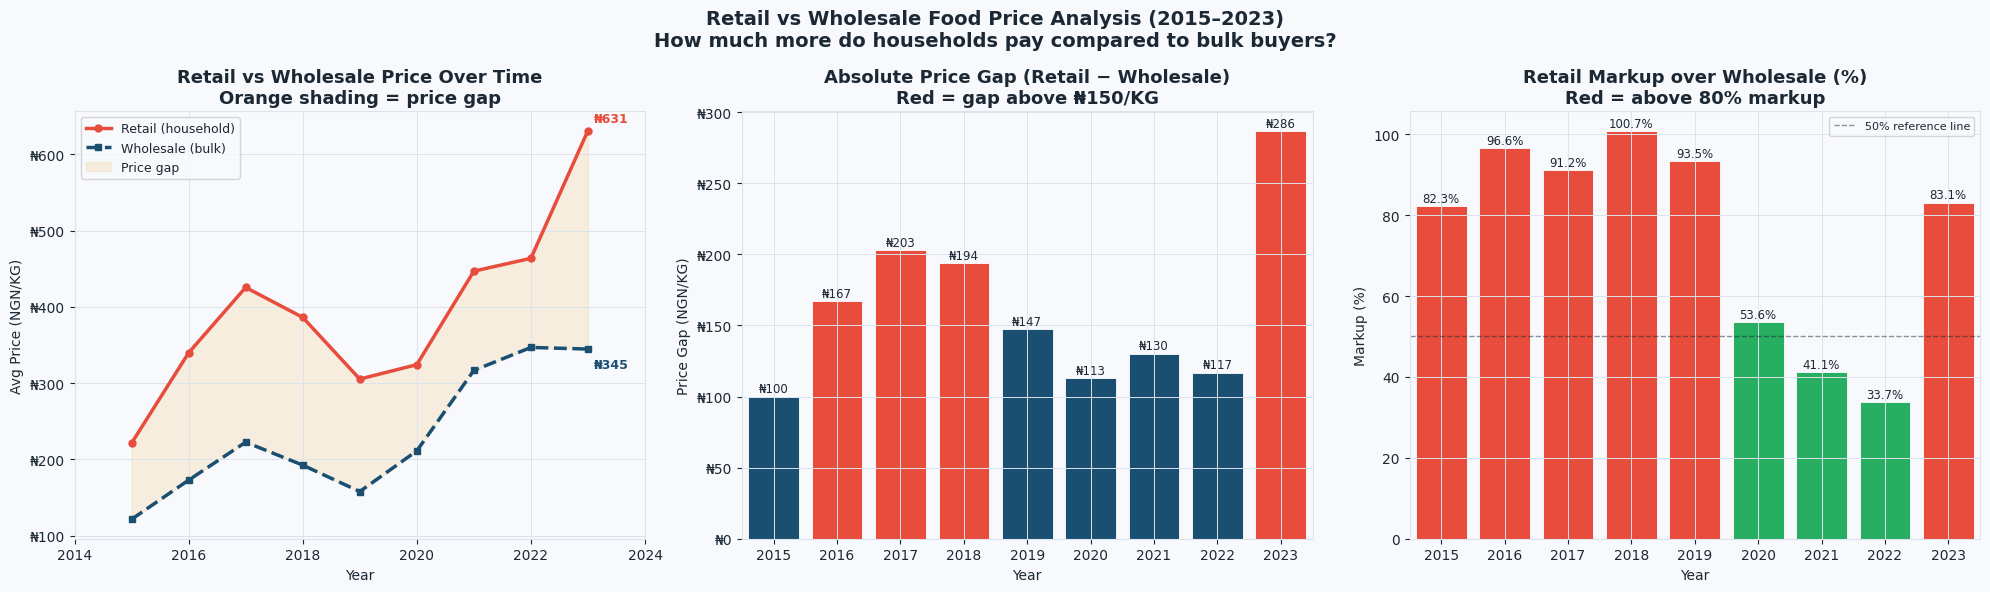

✅ Chart saved as 08_retail_vs_wholesale.png


In [42]:
# ── Plot Retail vs Wholesale ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Retail vs Wholesale Food Price Analysis (2015–2023)\n'
    'How much more do households pay compared to bulk buyers?',
    fontsize=14, fontweight='bold'
)

# ── Left: Retail vs Wholesale price lines ─────────────────────────────────────
ax = axes[0]
ax.plot(rw_plot.index, rw_plot['Retail'],
        color=ACCENT, linewidth=2.5,
        marker='o', markersize=5, label='Retail (household)')
ax.plot(rw_plot.index, rw_plot['Wholesale'],
        color=BLUE, linewidth=2.5,
        marker='s', markersize=5,
        linestyle='--', label='Wholesale (bulk)')
ax.fill_between(rw_plot.index,
                rw_plot['Retail'],
                rw_plot['Wholesale'],
                alpha=0.12, color='#F39C12',
                label='Price gap')

# Annotate 2023 values
ax.annotate(f'₦{rw_plot["Retail"].iloc[-1]:,.0f}',
            xy=(2023, rw_plot['Retail'].iloc[-1]),
            xytext=(4, 6), textcoords='offset points',
            fontsize=9, color=ACCENT, fontweight='bold')
ax.annotate(f'₦{rw_plot["Wholesale"].iloc[-1]:,.0f}',
            xy=(2023, rw_plot['Wholesale'].iloc[-1]),
            xytext=(4, -14), textcoords='offset points',
            fontsize=9, color=BLUE, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Retail vs Wholesale Price Over Time\nOrange shading = price gap')
ax.set_ylabel('Avg Price (NGN/KG)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.set_xlim(2014, 2024)

# ── Middle: Absolute price gap ────────────────────────────────────────────────
ax = axes[1]
colors_gap = [ACCENT if v > 150 else BLUE for v in rw_plot['abs_gap']]
bars = ax.bar(rw_plot.index, rw_plot['abs_gap'],
              color=colors_gap, edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, rw_plot['abs_gap']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 3, f'₦{val:,.0f}',
            ha='center', fontsize=8.5, color=TEXT_CLR)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Absolute Price Gap (Retail − Wholesale)\nRed = gap above ₦150/KG')
ax.set_ylabel('Price Gap (NGN/KG)')
ax.set_xlabel('Year')
ax.set_xlim(2014.5, 2023.5)

# ── Right: Markup percentage ──────────────────────────────────────────────────
ax = axes[2]
colors_pct = [ACCENT if v > 80 else '#27AE60' for v in rw_plot['markup_pct']]
bars = ax.bar(rw_plot.index, rw_plot['markup_pct'],
              color=colors_pct, edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, rw_plot['markup_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 1, f'{val:.1f}%',
            ha='center', fontsize=8.5, color=TEXT_CLR)

ax.axhline(50, color=TEXT_CLR, linewidth=1,
           linestyle='--', alpha=0.5, label='50% reference line')
ax.set_title('Retail Markup over Wholesale (%)\nRed = above 80% markup')
ax.set_ylabel('Markup (%)')
ax.set_xlabel('Year')
ax.set_xlim(2014.5, 2023.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('08_retail_vs_wholesale.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 08_retail_vs_wholesale.png")

---
## Commodity Affordability Ranking
Which foods are the most and least affordable in Nigeria right now?
This step ranks all commodities by their average price per KG using 
recent data (2020–2023) to reflect current market conditions.

This ranking is important for:
- Understanding which foods are within reach of poor households
- Identifying which commodities have crossed affordability thresholds
- Guiding food basket design and cash transfer value calculations
- Monitoring which foods are becoming rapidly unaffordable over time

We compare two periods — 2015–2019 vs 2020–2023 — to show how 
the affordability landscape has shifted in recent years.

In [43]:
# ── Average price per commodity — two periods ─────────────────────────────────
period1 = (kg_df_food[kg_df_food['year'].between(2015, 2019)]
           .groupby('commodity_grp')['price_per_kg']
           .mean()
           .round(2))

period2 = (kg_df_food[kg_df_food['year'].between(2020, 2023)]
           .groupby('commodity_grp')['price_per_kg']
           .mean()
           .round(2))

# ── Combine into one dataframe ────────────────────────────────────────────────
affordability = pd.DataFrame({
    '2015–2019': period1,
    '2020–2023': period2
}).dropna()

# ── Calculate price change between periods ────────────────────────────────────
affordability['change_pct'] = (
    (affordability['2020–2023'] - affordability['2015–2019']) /
    affordability['2015–2019'] * 100
).round(1)

# ── Sort by 2020–2023 price ───────────────────────────────────────────────────
affordability = affordability.sort_values('2020–2023', ascending=False)

print("=== Commodity Affordability Ranking ===")
print(affordability.to_string())

=== Commodity Affordability Ranking ===
                 2015–2019  2020–2023  change_pct
commodity_grp                                    
Meat               1145.12    1769.59        54.5
Oil                 586.59     848.35        44.6
Rice (imported)     371.87     669.87        80.1
Salt                932.36     596.60       -36.0
Sugar               474.81     546.16        15.0
Groundnuts          292.78     534.49        82.6
Rice (local)        294.21     455.72        54.9
Beans               339.88     420.96        23.9
Cowpeas             213.07     377.59        77.2
Fish                282.17     373.92        32.5
Oranges             218.39     343.30        57.2
Yam                 198.57     339.35        70.9
Gari/Cassava        147.01     276.39        88.0
Onions              206.92     247.59        19.7
Millet              124.77     227.57        82.4
Sorghum             113.41     214.20        88.9
Maize               123.05     213.94        73.9
Spinach   

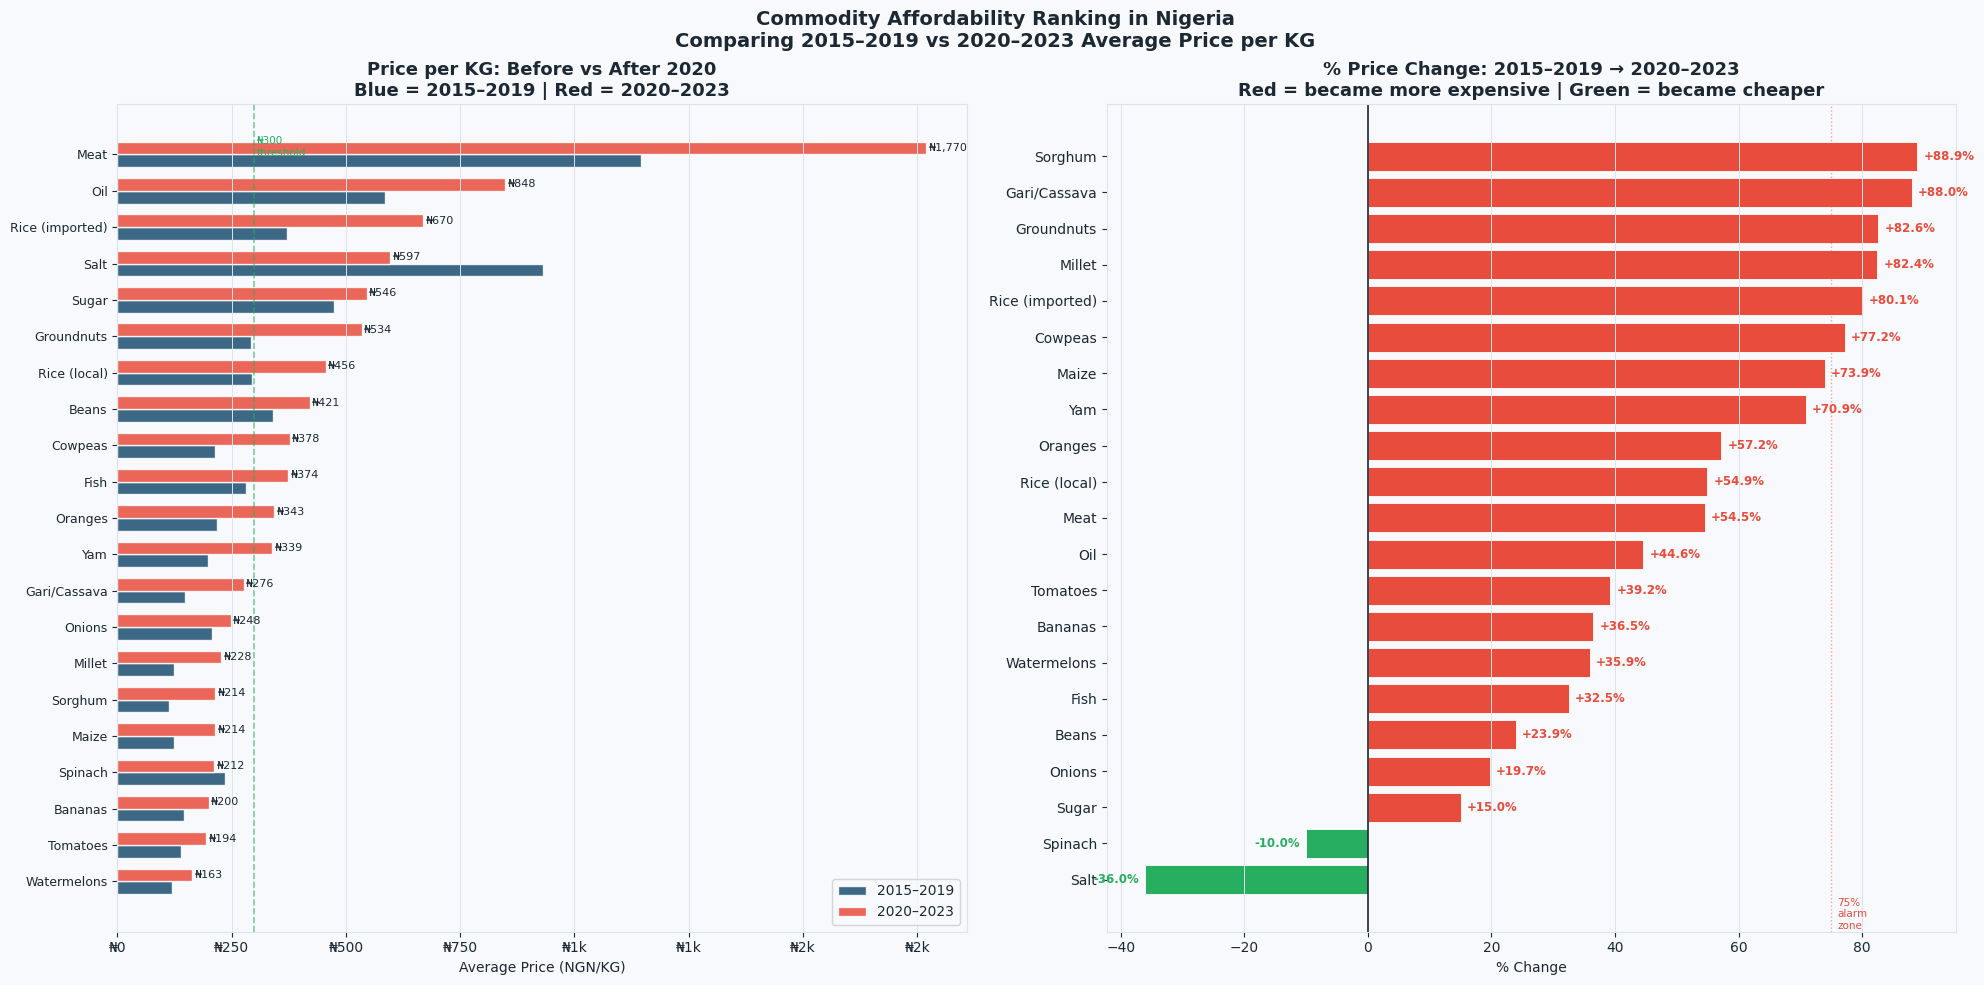

✅ Chart saved as 09_commodity_ranking.png


In [44]:
# ── Sort for plotting — cheapest to most expensive (2020–2023) ───────────────
aff_plot = affordability.sort_values('2020–2023', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(
    'Commodity Affordability Ranking in Nigeria\n'
    'Comparing 2015–2019 vs 2020–2023 Average Price per KG',
    fontsize=14, fontweight='bold'
)

# ── Left: Side by side bar chart — two periods ────────────────────────────────
ax = axes[0]

y      = np.arange(len(aff_plot))
height = 0.35

bars1 = ax.barh(y - height/2, aff_plot['2015–2019'],
                height, color=BLUE, alpha=0.85,
                label='2015–2019', edgecolor='white')
bars2 = ax.barh(y + height/2, aff_plot['2020–2023'],
                height, color=ACCENT, alpha=0.85,
                label='2020–2023', edgecolor='white')

# Annotate 2020–2023 price only
for bar, val in zip(bars2, aff_plot['2020–2023']):
    ax.text(val + 5,
            bar.get_y() + bar.get_height() / 2,
            f'₦{val:,.0f}',
            va='center', fontsize=8, color=TEXT_CLR)

ax.set_yticks(y)
ax.set_yticklabels(aff_plot.index, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_ngn))
ax.set_title('Price per KG: Before vs After 2020\nBlue = 2015–2019 | Red = 2020–2023')
ax.set_xlabel('Average Price (NGN/KG)')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0)

# Add affordability zone labels
ax.axvline(300, color='#27AE60', linewidth=1.2,
           linestyle='--', alpha=0.6, label='₦300 threshold')
ax.text(305, len(aff_plot) - 0.5, '₦300\nthreshold',
        fontsize=7.5, color='#27AE60', va='top')

# ── Right: Percentage change bar chart ───────────────────────────────────────
ax = axes[1]

# Sort by change percentage for this panel
aff_chg = affordability.sort_values('change_pct', ascending=True)
colors_chg = [ACCENT if v > 0 else '#27AE60'
              for v in aff_chg['change_pct']]

bars = ax.barh(aff_chg.index, aff_chg['change_pct'],
               color=colors_chg, edgecolor='white', linewidth=0.6)

ax.axvline(0, color=TEXT_CLR, linewidth=1.2)

# Annotate each bar
for bar, val in zip(bars, aff_chg['change_pct']):
    offset = 1 if val >= 0 else -1
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f}%',
            va='center', ha=ha, fontsize=8.5,
            color=ACCENT if val > 0 else '#27AE60',
            fontweight='bold')

ax.set_title('% Price Change: 2015–2019 → 2020–2023\nRed = became more expensive | Green = became cheaper')
ax.set_xlabel('% Change')
ax.grid(axis='y', alpha=0)

# Highlight the most alarming increases
ax.axvline(75, color=ACCENT, linewidth=1,
           linestyle=':', alpha=0.5)
ax.text(76, -0.5, '75%\nalarm\nzone',
        fontsize=7.5, color=ACCENT, va='top')

plt.tight_layout()
plt.savefig('09_commodity_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 09_commodity_ranking.png")

---
# State × Commodity Price Heatmap
This is our final synthesis chart. It combines everything we have learned 
about regional differences and commodity prices into a single visual matrix.

For each state and commodity combination we show the average price per KG 
from 2018–2023 — our most reliable and recent period. The colour intensity 
shows relative expense — darker red means that state pays more for that 
commodity compared to other states. The actual price in NGN is shown inside 
each cell.

This chart is designed as an operational reference tool — a programme officer 
can look at any state row and immediately see which commodities are most 
expensive there, or look at any commodity column and see which states are 
most affected.

In [45]:
# ── Define commodities and states to include ──────────────────────────────────
HEATMAP_COMMODITIES = [
    'Maize', 'Millet', 'Sorghum', 'Rice (imported)',
    'Rice (local)', 'Beans', 'Cowpeas', 'Groundnuts',
    'Gari/Cassava', 'Yam', 'Oil', 'Meat', 'Fish',
    'Onions', 'Tomatoes'
]

# ── Build the matrix ──────────────────────────────────────────────────────────
heat_data = (kg_df_food[
    (kg_df_food['year'] >= 2018) &
    (kg_df_food['commodity_grp'].isin(HEATMAP_COMMODITIES))
]
.groupby(['state', 'commodity_grp'])['price_per_kg']
.mean()
.round(0)
.unstack())

# ── Check coverage ────────────────────────────────────────────────────────────
print("=== Heatmap Matrix Shape ===")
print(f"States: {heat_data.shape[0]}")
print(f"Commodities: {heat_data.shape[1]}")
print(f"\nMissing values per commodity:")
print(heat_data.isnull().sum().sort_values(ascending=False))
print(f"\nMissing values per state:")
print(heat_data.isnull().sum(axis=1).sort_values(ascending=False))

=== Heatmap Matrix Shape ===
States: 14
Commodities: 15

Missing values per commodity:
commodity_grp
Oil                12
Beans              11
Fish               11
Meat               11
Onions             11
Tomatoes           11
Cowpeas             1
Gari/Cassava        1
Groundnuts          1
Maize               1
Rice (imported)     1
Rice (local)        1
Sorghum             1
Yam                 1
Millet              0
dtype: int64

Missing values per state:
state
Sokoto     14
Abia        6
Gombe       6
Jigawa      6
Kaduna      6
Kano        6
Katsina     6
Kebbi       6
Lagos       6
Oyo         6
Zamfara     6
Adamawa     1
Borno       0
Yobe        0
dtype: int64


In [46]:
# ── Drop Sokoto — no data in our period ──────────────────────────────────────
heat_data = heat_data.drop('Sokoto', errors='ignore')

# ── Keep only commodities with data in at least 8 states ─────────────────────
coverage_threshold = 8
well_covered = heat_data.columns[
    heat_data.notna().sum() >= coverage_threshold
].tolist()

print("Well covered commodities:", well_covered)

heat_data = heat_data[well_covered]

print(f"\nFinal matrix shape: {heat_data.shape}")
print(f"States: {heat_data.shape[0]}")
print(f"Commodities: {heat_data.shape[1]}")
print(f"\nRemaining missing values:")
print(heat_data.isnull().sum().sort_values(ascending=False))
print(f"\nMatrix preview:")
print(heat_data.round(0).to_string())

Well covered commodities: ['Cowpeas', 'Gari/Cassava', 'Groundnuts', 'Maize', 'Millet', 'Rice (imported)', 'Rice (local)', 'Sorghum', 'Yam']

Final matrix shape: (13, 9)
States: 13
Commodities: 9

Remaining missing values:
commodity_grp
Cowpeas            0
Gari/Cassava       0
Groundnuts         0
Maize              0
Millet             0
Rice (imported)    0
Rice (local)       0
Sorghum            0
Yam                0
dtype: int64

Matrix preview:
commodity_grp  Cowpeas  Gari/Cassava  Groundnuts  Maize  Millet  Rice (imported)  Rice (local)  Sorghum    Yam
state                                                                                                         
Abia             717.0         399.0       709.0  295.0   408.0            638.0         468.0    424.0  258.0
Adamawa          334.0         249.0       445.0  172.0   205.0            537.0         320.0    204.0  754.0
Borno            326.0         235.0       523.0  219.0   218.0            685.0         456.0    199

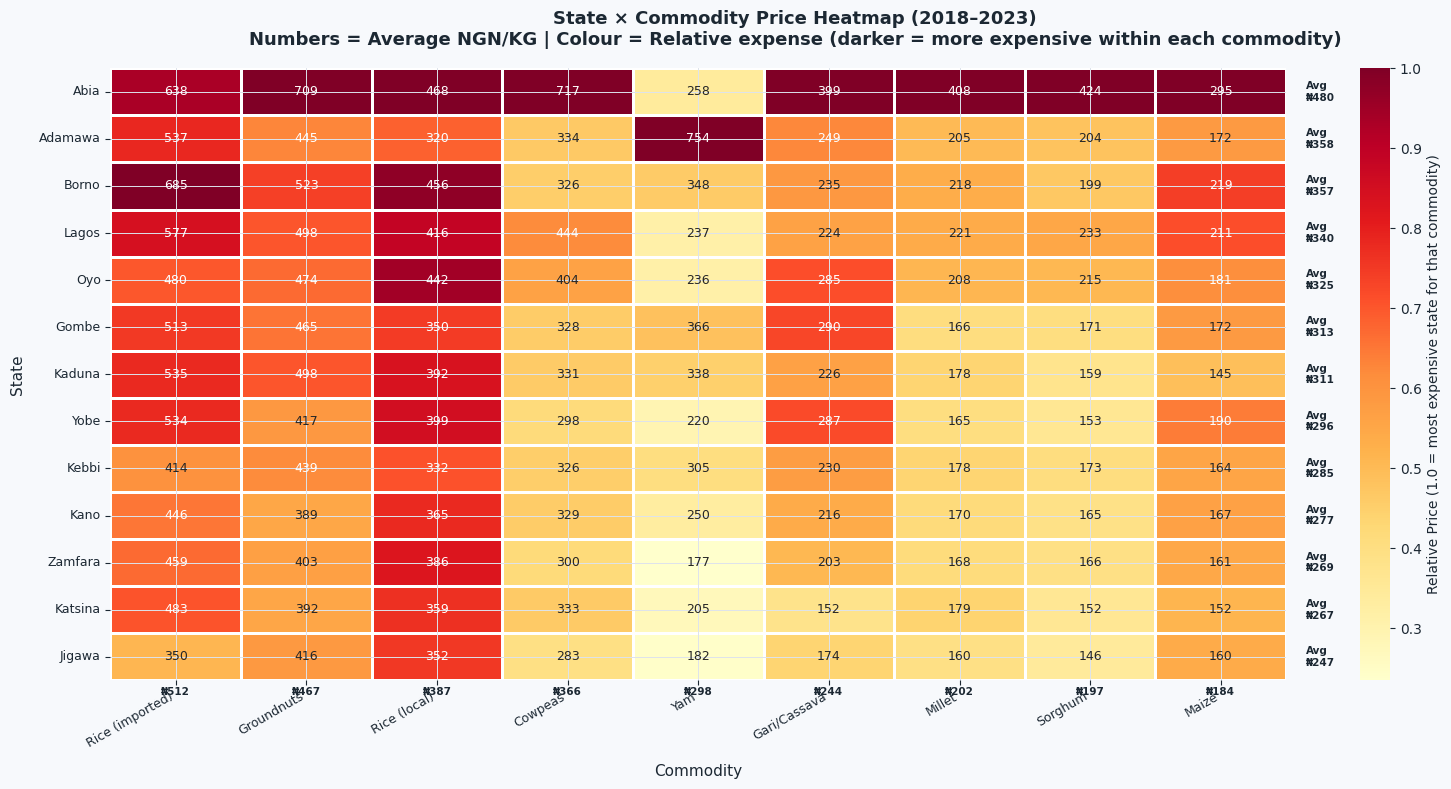

✅ Chart saved as 10_heatmap_state_commodity.png


In [47]:
# ── Normalise per column for colour scaling ───────────────────────────────────
# Each commodity column scaled 0-1 so colours show relative expense per commodity
# Actual NGN values shown as annotations inside cells
heat_norm = heat_data.div(heat_data.max())

# ── Order states by overall average price (most expensive at top) ─────────────
state_order = heat_data.mean(axis=1).sort_values(ascending=False).index
heat_data   = heat_data.loc[state_order]
heat_norm   = heat_norm.loc[state_order]

# ── Order commodities by overall average (most expensive left) ────────────────
comm_order  = heat_data.mean(axis=0).sort_values(ascending=False).index
heat_data   = heat_data[comm_order]
heat_norm   = heat_norm[comm_order]

fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle(
    'State × Commodity Price Heatmap (2018–2023)\n'
    'Numbers = Average NGN/KG | Colour = Relative expense '
    '(darker = more expensive within each commodity)',
    fontsize=13, fontweight='bold'
)

# ── Draw heatmap ──────────────────────────────────────────────────────────────
sns.heatmap(
    heat_norm,
    annot=heat_data.astype(int),
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Relative Price (1.0 = most expensive state for that commodity)'},
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('')
ax.set_xlabel('Commodity', fontsize=11, labelpad=10)
ax.set_ylabel('State', fontsize=11, labelpad=10)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

# ── Add state row average as extra annotation on right ────────────────────────
row_avgs = heat_data.mean(axis=1).round(0).astype(int)
for i, (state, avg) in enumerate(row_avgs.items()):
    ax.text(heat_data.shape[1] + 0.15, i + 0.5,
            f'Avg\n₦{avg:,}',
            va='center', fontsize=7.5,
            color=TEXT_CLR, fontweight='bold')

# ── Add commodity column average as annotation on bottom ──────────────────────
col_avgs = heat_data.mean(axis=0).round(0).astype(int)
for j, (comm, avg) in enumerate(col_avgs.items()):
    ax.text(j + 0.5, heat_data.shape[0] + 0.15,
            f'₦{avg:,}',
            va='top', ha='center', fontsize=7.5,
            color=TEXT_CLR, fontweight='bold')

plt.tight_layout()
plt.savefig('10_heatmap_state_commodity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 10_heatmap_state_commodity.png")

---
##  Conclusions & Recommendations

### What the Data Tells Us
1. **The crisis is structural not cyclical** — prices have risen every year 
   since 2020 with no recovery year in between
2. **Currency depreciation explains much of the NGN price increase** — 
   but 2023 saw genuine real food inflation on top of depreciation
3. **Geography determines food security** — conflict-affected northeast 
   states face prices 50–60% above national average
4. **Protein is becoming systematically unaffordable** — all protein 
   sources rose 32–83% since 2020
5. **The lean season creates predictable annual vulnerability** — June 
   to September prices are 12–15% above harvest season lows
6. **Supply chain markups compound every other pressure** — retail adds 
   40–100% above wholesale consistently

### Recommendations
- Review all transfer values calibrated before 2020 — they have lost 
  50–89% of their purchasing power in food terms
- Calibrate interventions geographically — a single national transfer 
  value is inadequate given 50–60% price gaps between states
- Pre-position assistance in May before lean season peaks rather than 
  responding in August after households have already reduced meals
- Monitor sorghum and gari prices as early warning indicators — these 
  last-resort foods rising fastest signals the most severe household stress
- Include dietary diversity indicators alongside food security metrics — 
  households may meet caloric needs while facing severe nutritional insecurity

### Limitations
- Dataset covers 14 of Nigeria's 36 states — findings not fully 
  representative of the entire country
- Sokoto data ends in 2019 limiting recent comparisons
- Some commodity-state combinations have thin coverage requiring caution
- Analysis covers prices only — income, expenditure and consumption 
  data needed for full food security picture

In [48]:
# Run this in a code cell to confirm your notebook is clean
print("Total cells with output:", "check manually")
print("Charts saved:", 10)
print("No error cells remaining: confirm visually")

# Restart kernel and run all cells from top to bottom
# If it runs clean end to end your notebook is portfolio ready

Total cells with output: check manually
Charts saved: 10
No error cells remaining: confirm visually
